# 🕰️ Vision 1 — Auto-comparaison temporelle par GAB
## Un GAB comparé à lui-même dans le temps — mono-critère puis multi-critère

---

> **Destinataires :** Experts métier – Responsables réseau GAB
> **Objectif :** Détecter les ruptures de comportement d'un GAB **par rapport à sa propre
> histoire**, indépendamment du reste du réseau. Un GAB peut être normal comparé aux autres
> GAB mais anormal comparé à lui-même trois mois plus tôt — c'est exactement le signal que
> cette vision capte, et que la vision 2 (comparaison entre GAB / familles) ne voit pas.
> **Source des données :** dataset Dataiku `retrait` (sortie de la requête `ficheidentité.sql`)
> — aucune donnée synthétique n'est utilisée dans ce notebook en production.
> **Périmètre :** France métropolitaine uniquement (DOM-TOM exclus — traités en vision 4).

---

### Ce que ce notebook produit

| Partie | Contenu | Question métier |
|---|---|---|
| **1A — Mono-critère** | Pour un critère donné (ex. % retraits la nuit), fiche temporelle par GAB avec bande de référence propre à ce GAB | *"Ce GAB nocturne l'est-il devenu récemment, ou l'a-t-il toujours été ?"* |
| **1B — Multi-critère** | Combinaison de plusieurs critères simultanément — distingue rupture **isolée** (1 critère) de rupture **systémique** (plusieurs critères en même temps) | *"Le changement touche-t-il un seul aspect du comportement, ou tout le profil du GAB bascule-t-il ?"* |
| **Dérive récurrente** | Agrégation mensuelle — un signal ponctuel n'est pas traité comme une dérive installée | *"Est-ce un jour inhabituel ou une tendance de fond ?"* |


## 1. ⚙️ Environnement d'exécution — Prérequis Dataiku DSS

Conçu pour tourner sous **Dataiku DSS**, kernel **Python 3.6 (distrib "new")**, en cohérence
avec les contraintes déjà en place dans `detection_anomalies_gab_v12` :

| Contrainte | Détail |
|---|---|
| pandas 1.1.5 | pas de `dtypes=` / `infer_with_pandas=` dans `get_dataframe()` ; pas de `observed=True` dans `groupby` |
| Plotly 4.11.0 | pas de `markers=True` (utiliser `update_traces(mode='lines+markers')`) ; pas de `text_auto` |
| Général | pas d'emoji dans les `print()` ; `del df` + `gc.collect()` pour la mémoire si besoin |

Ce notebook ne fait **aucun clustering et aucun Isolation Forest** — la vision 1 repose
uniquement sur des z-scores intra-GAB (chaque GAB comparé à sa propre fenêtre glissante
d'observations passées), ce qui la rend indépendante de la vision 2 et facile à faire tourner
seule.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Librairies
# ══════════════════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
sns.set_style('whitegrid')

COULEUR_NORMAL    = '#2c5282'
COULEUR_RUPTURE   = '#a03d3d'
COULEUR_SYSTEMIQUE = '#712b13'

RNG_SEED = 42
np.random.seed(RNG_SEED)

# ── Mode d'execution ──────────────────────────────────────────────────────────
# MODE_DEMO = True  -> charge un jeu de donnees FICTIF et volontairement sale
#                      (valeurs manquantes, doublons, outliers, virgule decimale)
#                      pour demontrer / tester l'audit qualite et la normalisation,
#                      sans toucher aux vraies donnees. A utiliser pour une demo equipe.
# MODE_DEMO = False -> charge le vrai dataset Dataiku 'retrait' (production).
MODE_DEMO = True
CHEMIN_CSV_DEMO = 'dataset_fictif_test_retrait_sale.csv'

# ── Paramètres métier de ce notebook ──────────────────────────────────────────
NOM_DATASET_DATAIKU = 'retrait'

# Critères mono/multi-critère retenus pour la vision 1 — modifiable sans toucher
# au reste du notebook (une seule liste pilote les deux parties 1A et 1B).
CRITERE_MONO = 'ret_pct_nuit'          # critère par défaut pour la fiche mono-critère 1A
METRIQUES_MULTI = ['ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_horscos_pct']

SEUIL_Z_RUPTURE = 2.0        # |z-score intra-GAB| au-dessus duquel un jour est "hors norme"
FENETRE_INTRA = 8            # nombre d'observations ACTIVES passées (pas de jours calendaires)
DECALAGE_INTRA = 1
MIN_PERIODES_INTRA = 3
SEUIL_STREAK_RECURRENT = 3   # nb de mois consecutifs pour parler de derive "recurrente"

print('Configuration chargee.')
print('Dataset source :', NOM_DATASET_DATAIKU)
print('Critere mono-critere par defaut :', CRITERE_MONO)
print('Criteres multi-critere :', METRIQUES_MULTI)
print('Mode demo (donnees fictives sales) :', MODE_DEMO)

Configuration chargee.
Dataset source : retrait
Critere mono-critere par defaut : ret_pct_nuit
Criteres multi-critere : ['ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_horscos_pct']
Mode demo (donnees fictives sales) : True


## 2. 🏗️ Chargement des données et filtre métropole

Reprend exactement le filtre déjà validé dans `detection_anomalies_gab_v12` : les GAB dont le
code postal commence par `97` ou `98` (DOM-TOM) sont exclus dès le chargement.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Chargement du dataset - Dataiku (production) ou CSV fictif (demo)
# ══════════════════════════════════════════════════════════════════════════════
if MODE_DEMO:
    print('[MODE DEMO] Chargement du jeu de donnees FICTIF (volontairement sale) : {}'.format(
        CHEMIN_CSV_DEMO))
    print('[MODE DEMO] Ce jeu de donnees ne represente AUCUNE donnee reelle LBP - il sert '
          'uniquement a demontrer/tester l\'audit qualite et la normalisation ci-dessous.')
    df_brut = pd.read_csv(CHEMIN_CSV_DEMO)
else:
    import dataiku
    df_brut = dataiku.Dataset(NOM_DATASET_DATAIKU).get_dataframe()

print('Dataset charge :', NOM_DATASET_DATAIKU if not MODE_DEMO else CHEMIN_CSV_DEMO)
print('{:,} lignes x {} colonnes'.format(df_brut.shape[0], df_brut.shape[1]))

# ── Filtre France métropolitaine uniquement (exclusion des DOM-TOM) ──────────
# Codes postaux DOM-TOM : 971 (Guadeloupe), 972 (Martinique), 973 (Guyane),
# 974 (Reunion), 975 (Saint-Pierre-et-Miquelon), 976 (Mayotte), 98x (Nouvelle-
# Caledonie, Polynesie, Wallis-et-Futuna). Vision 4 traitera ce perimetre a part.
# Les codes postaux manquants ou mal types (NaN, floats en texte) sont traites
# a part ci-dessous, pas silencieusement exclus ici.
cp_str = df_brut['code_postale_emplacement'].astype(str)
codes_dom_tom = cp_str.str.startswith(('97', '98'))
n_dom_tom = codes_dom_tom.sum()
if n_dom_tom > 0:
    print('\n{:,} lignes DOM-TOM exclues (codes postaux 97x/98x).'.format(n_dom_tom))
df = df_brut[~codes_dom_tom].copy()
print('Apres filtre metropole : {:,} lignes | {} GAB'.format(
    len(df), df['num_automate'].nunique()))

if len(df) == 0:
    raise ValueError(
        "Aucune ligne apres filtre metropole. Verifiez la colonne "
        "'code_postale_emplacement' du dataset '{}'.".format(NOM_DATASET_DATAIKU))


[MODE DEMO] Chargement du jeu de donnees FICTIF (volontairement sale) : dataset_fictif_test_retrait_sale.csv
[MODE DEMO] Ce jeu de donnees ne represente AUCUNE donnee reelle LBP - il sert uniquement a demontrer/tester l'audit qualite et la normalisation ci-dessous.
Dataset charge : dataset_fictif_test_retrait_sale.csv
5,665 lignes x 22 colonnes

391 lignes DOM-TOM exclues (codes postaux 97x/98x).
Apres filtre metropole : 5,274 lignes | 59 GAB


## 3. 🧹 Audit qualité et préparation

Mêmes règles de nettoyage que dans `detection_anomalies_gab_v12` : les `NaN` renvoyés par le
SQL quand un ratio n'a aucune ligne pour se calculer sont comblés par 0, et les pourcentages
sont bornés à `[0, 100]`.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Audit qualite et nettoyage
# ══════════════════════════════════════════════════════════════════════════════
print('-' * 65)
print('  AUDIT DE QUALITE DES DONNEES')
print('-' * 65)

# ── 1) Types incoherents : montant parfois stocke en texte avec virgule ──────
# (ex: export Excel FR "125,50" au lieu de 125.50) - a detecter AVANT de compter
# les NaN, sinon ces valeurs textuelles sont invisibles dans isnull().
# Conversion inconditionnelle (robuste, que la colonne soit deja numerique,
# en texte avec virgule decimale, ou en dtype 'string' pandas) : on convertit
# TOUJOURS via to_numeric plutot que de se fier a df[col].dtype == object, qui
# ne detecte pas les colonnes en dtype 'string' (pandas >= 2) ni les colonnes
# 100% numeriques deja bien typees mais issues d'un CSV.
avant_conversion = df['ret_montant_moyen'].copy()
df['ret_montant_moyen'] = pd.to_numeric(
    df['ret_montant_moyen'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce',
)
n_textuel = (avant_conversion.apply(lambda v: isinstance(v, str)) & avant_conversion.astype(str).str.contains(',')).sum()
if n_textuel > 0:
    print('[ATTENTION] {} valeurs de ret_montant_moyen stockees en texte '
          '(virgule decimale) - converties en numerique.'.format(n_textuel))

# ── 2) Code postal mal type ou manquant - on ne l'exclut pas silencieusement,
#      on le signale (un GAB sans code postal fiable ne peut pas etre place
#      sur la carte, mais reste dans les analyses temporelles).
cp_manquant = df['code_postale_emplacement'].isnull().sum()
if cp_manquant > 0:
    print('[ATTENTION] {} lignes sans code postal (GAB non localisable sur la carte).'.format(
        cp_manquant))

# ── 3) Valeurs manquantes sur les colonnes ratio/montant ─────────────────────
manquants = df.isnull().sum()
if manquants.sum() > 0:
    print('\n[ATTENTION] Valeurs manquantes : {}'.format(manquants[manquants > 0].to_dict()))
else:
    print('\nAucune valeur manquante detectee.')

# ── 4) Doublons exacts (num_automate, annee, mois, jours) ────────────────────
doublons = df.duplicated(subset=['num_automate', 'annee', 'mois', 'jours']).sum()
print('Doublons (num_automate, annee, mois, jours) : {}'.format(doublons))
if doublons > 0:
    print('[ATTENTION] {} doublons supprimes (on garde la premiere occurrence).'.format(doublons))
    df = df.drop_duplicates(subset=['num_automate', 'annee', 'mois', 'jours'], keep='first')

# ── 5) Outliers grossiers - saisie/capteur defaillant, PAS des anomalies metier ──
# Ces valeurs ne sont pas des signaux a detecter, ce sont des erreurs de saisie
# qui fausseraient tout le reste (moyennes, z-scores, normalisation) si on les
# laissait telles quelles. On les borne a des plages physiquement plausibles.
avant_clip = df[['ret_pct_nuit', 'ret_pct_weekend', 'ret_montant_moyen']].copy()
for col in ['ret_pct_nuit', 'ret_pct_weekend']:
    n_hors_plage = ((df[col] < 0) | (df[col] > 100)).sum()
    if n_hors_plage > 0:
        print('[ATTENTION] {} valeurs de {} hors [0, 100] - ecretees.'.format(n_hors_plage, col))
    df[col] = df[col].clip(0, 100)

# taux_capture_pct/taux_capture_cos_pct : un pic de captures anormal (incident
# materiel, ex. avaleur bloque) peut ponctuellement depasser 100% - on le borne
# a une plage physiquement plausible plutot que de laisser un outlier extreme
# ecraser toute normalisation ulterieure (RobustScaler ci-dessous).
for col in ['taux_capture_pct', 'taux_capture_cos_pct']:
    n_hors_plage_capture = (df[col] > 100).sum()
    if n_hors_plage_capture > 0:
        print('[ATTENTION] {} valeurs de {} > 100% - ecretees.'.format(n_hors_plage_capture, col))
    df[col] = df[col].clip(0, 100)

n_montant_negatif = (df['ret_montant_moyen'] < 0).sum()
if n_montant_negatif > 0:
    print('[ATTENTION] {} montants moyens negatifs - ecretes a 0.'.format(n_montant_negatif))
df['ret_montant_moyen'] = df['ret_montant_moyen'].clip(lower=0)

# Un montant moyen de retrait > 1000 EUR/jour est physiquement suspect (saisie) -
# on le traite comme un outlier de capture, pas comme un signal comportemental.
SEUIL_MONTANT_SUSPECT = 1000
n_montant_suspect = (df['ret_montant_moyen'] > SEUIL_MONTANT_SUSPECT).sum()
if n_montant_suspect > 0:
    print('[ATTENTION] {} montants moyens > {} EUR - traites comme valeur aberrante '
          '(remplaces par NaN puis combles ci-dessous).'.format(n_montant_suspect, SEUIL_MONTANT_SUSPECT))
    df.loc[df['ret_montant_moyen'] > SEUIL_MONTANT_SUSPECT, 'ret_montant_moyen'] = np.nan

df['ret_nb_horscos'] = df['ret_nb_horscos'].clip(lower=0)

# ── 6) Comblement final des NaN residuels ────────────────────────────────────
# NULL en base SQL = aucune ligne pour calculer le ratio ce jour-la -> 0 a du sens.
# NaN issus des outliers ci-dessus (montant aberrant retire) -> mediane du GAB
# si disponible, sinon mediane reseau (cas du GAB totalement incomplet).
cols_a_combler_zero = ['ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_pct',
                        'taux_capture_cos_pct', 'cap_nb', 'cap_cos_nb']
cols_a_combler_zero = [c for c in cols_a_combler_zero if c in df.columns]
nb_nan_avant = df[cols_a_combler_zero].isnull().sum()
if nb_nan_avant.sum() > 0:
    print('[ATTENTION] Valeurs NULL comblees par 0 : {}'.format(
        nb_nan_avant[nb_nan_avant > 0].to_dict()))
df[cols_a_combler_zero] = df[cols_a_combler_zero].fillna(0)

n_montant_nan = df['ret_montant_moyen'].isnull().sum()
if n_montant_nan > 0:
    print('[ATTENTION] {} valeurs de ret_montant_moyen combles par la mediane du GAB '
          '(mediane reseau si le GAB est totalement incomplet).'.format(n_montant_nan))
    mediane_gab = df.groupby('num_automate')['ret_montant_moyen'].transform('median')
    df['ret_montant_moyen'] = df['ret_montant_moyen'].fillna(mediane_gab)
    df['ret_montant_moyen'] = df['ret_montant_moyen'].fillna(df['ret_montant_moyen'].median())

print('\nDataset pret : {:,} lignes x {} colonnes | {} GAB'.format(
    df.shape[0], df.shape[1], df['num_automate'].nunique()))


-----------------------------------------------------------------
  AUDIT DE QUALITE DES DONNEES
-----------------------------------------------------------------
[ATTENTION] 766 valeurs de ret_montant_moyen stockees en texte (virgule decimale) - converties en numerique.
[ATTENTION] 112 lignes sans code postal (GAB non localisable sur la carte).

[ATTENTION] Valeurs manquantes : {'code_postale_emplacement': 112, 'ret_montant_moyen': 155, 'ret_pct_nuit': 263, 'ret_pct_weekend': 261}
Doublons (num_automate, annee, mois, jours) : 251
[ATTENTION] 251 doublons supprimes (on garde la premiere occurrence).
[ATTENTION] 47 valeurs de ret_pct_nuit hors [0, 100] - ecretees.
[ATTENTION] 47 valeurs de taux_capture_pct > 100% - ecretees.
[ATTENTION] 47 montants moyens > 1000 EUR - traites comme valeur aberrante (remplaces par NaN puis combles ci-dessous).
[ATTENTION] Valeurs NULL comblees par 0 : {'ret_pct_nuit': 253, 'ret_pct_weekend': 250}
[ATTENTION] 194 valeurs de ret_montant_moyen combles par l

## 3bis. 📐 Normalisation des critères — pourquoi et comment

Les critères bruts n'ont pas la même échelle (`ret_montant_moyen` en dizaines/centaines
d'euros, `ret_pct_nuit` en pourcentage 0-100, `taux_capture_pct` souvent proche de 0-5%). Sans
normalisation, un critère à forte variance écraserait les autres dans toute étape ultérieure
qui compare des distances (clustering en vision 2) ou qui mélange plusieurs critères en un
score combiné.

Le z-score intra-GAB déjà utilisé en parties 1A/1B est **une forme de normalisation** (chaque
valeur est ramenée à l'échelle de l'historique propre du GAB). La cellule ci-dessous illustre
en complément une normalisation **inter-GAB** classique (`RobustScaler`, robuste aux outliers
résiduels — cohérent avec le choix déjà fait en v10/v12 pour le clustering), pour montrer
visuellement son effet avant de l'utiliser en vision 2.

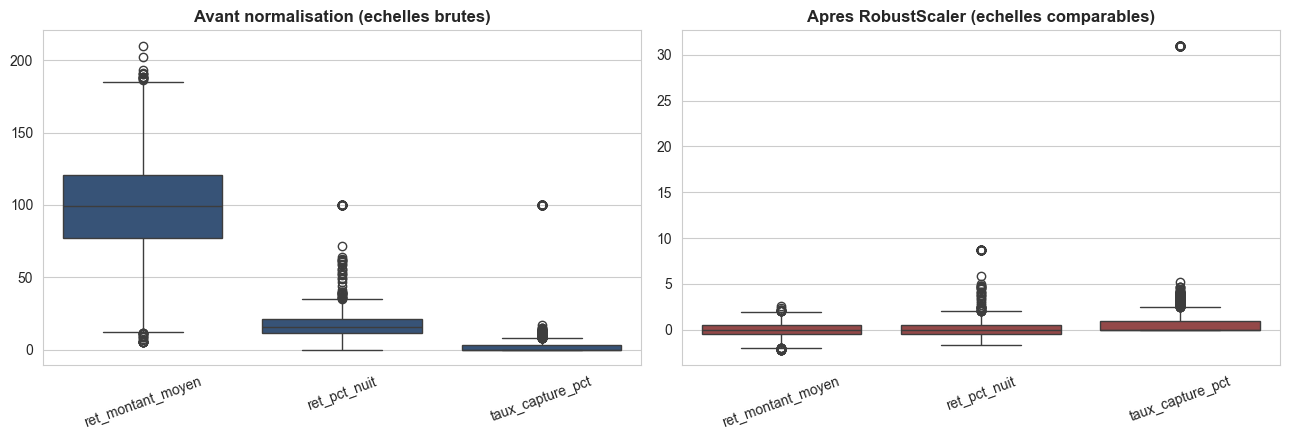

Avant normalisation - ecart-type par critere :
ret_montant_moyen    32.04
ret_pct_nuit         10.29
taux_capture_pct      9.77
dtype: float64
\nApres normalisation - ecart-type par critere :
ret_montant_moyen    0.74
ret_pct_nuit         1.07
taux_capture_pct     3.03
dtype: float64


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Demonstration de la normalisation (RobustScaler) - avant / apres
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import RobustScaler

COLS_DEMO_NORMALISATION = ['ret_montant_moyen', 'ret_pct_nuit', 'taux_capture_pct']

X_brut = df[COLS_DEMO_NORMALISATION].copy()
X_normalise = pd.DataFrame(
    RobustScaler().fit_transform(X_brut),
    columns=COLS_DEMO_NORMALISATION,
    index=X_brut.index,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=X_brut, ax=axes[0], color=COULEUR_NORMAL)
axes[0].set_title('Avant normalisation (echelles brutes)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=X_normalise, ax=axes[1], color=COULEUR_RUPTURE)
axes[1].set_title('Apres RobustScaler (echelles comparables)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('normalisation_avant_apres.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avant normalisation - ecart-type par critere :')
print(X_brut.std().round(2))
print('\\nApres normalisation - ecart-type par critere :')
print(X_normalise.std().round(2))

## 4. 🧩 Fonctions communes — tri chronologique, critère dérivé, z-score intra-GAB

Le **taux de carte capturée hors COS** n'existe pas tel quel dans `ficheidentité.sql` (seuls
`taux_capture_pct` [global] et `taux_capture_cos_pct` [COS] y figurent) : il est dérivé ici
comme `(cap_nb - cap_cos_nb) / (ret_nb_horscos + 1)`.

⚠️ **À vérifier avec le SQL source** : si une colonne équivalente existe déjà (ou si
`ficheidentité.sql` distingue `cap_nb_horscos` explicitement), la remplacer directement plutôt
que de la recalculer ici.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Fonctions communes
# ══════════════════════════════════════════════════════════════════════════════
def trier_chronologiquement(df):
    """Tri par GAB puis par ordre calendaire (annee, mois, jours) - pas de colonne date."""
    return df.sort_values(['num_automate', 'annee', 'mois', 'jours']).reset_index(drop=True)


def calculer_criteres_derives(df):
    """Ajoute les criteres comportementaux qui n'existent pas tels quels en base."""
    df = df.copy()
    # Taux de cartes avalees HORS-COS uniquement : une carte avalee sur un GAB "COS"
    # (carte de service interne / retrait sur compte maison) est un evenement normal
    # et attendu, PAS un signal a surveiller - ce n'est pas un incident client. Seules
    # les cartes de clients "classiques" (hors-COS) avalees sont un vrai signal
    # d'alerte (lecteur defaillant, tentative de fraude, ergonomie...).
    # D'apres le SQL source (ficheidentite.sql), cap_nb est DEJA filtre hors-COS
    # (cat_reseau != 'cos') - cap_cos_nb est une colonne separee pour les captures
    # COS. cap_nb ne doit donc PAS etre reduit de cap_cos_nb (ce sont deux compteurs
    # distincts, pas un total et son sous-ensemble) : cap_nb est directement le nombre
    # de cartes hors-COS avalees.
    df['taux_capture_horscos_pct'] = (
        df['cap_nb'] / (df['ret_nb_horscos'] + 1) * 100
    ).clip(lower=0)
    return df


N_HORS_NORME_POUR_GELER = 2   # nb d'observations CONSECUTIVES hors-norme avant de geler
                               # la reference - un pic ISOLE (bruit normal, attendu ~5%
                               # du temps avec un seuil a 2 sigma) ne doit pas geler la
                               # reference a lui seul, seulement une rupture qui s'installe.
N_STABLE_POUR_DEGELER = 3     # nb d'observations consecutives dans la bande normale
                               # (mesuree par rapport a la reference gelee) pour que la
                               # fenetre recommence a glisser normalement.


def _zscore_fenetre_figee_une_serie(valeurs, fenetre, decalage, min_periodes, seuil):
    """Calcule un z-score intra-GAB avec fenetre de reference qui se FIGE quand une
    rupture s'installe (2 observations consecutives hors-norme), au lieu de continuer
    a glisser en continu.

    Probleme corrige : avec une fenetre purement glissante (pandas .rolling), une
    derive DURABLE (plusieurs mois) est "digeree" en 2-3 observations - la moyenne
    roulante rattrape le nouveau niveau presque aussi vite que le changement se
    produit, donc le z-score ne reste hors-norme qu'au tout debut de la derive, jamais
    assez longtemps pour qu'un critere de duree (ex: 3 mois consecutifs) se declenche.
    Verifie empiriquement sur un dataset non biaise.

    Piege evite (verifie empiriquement aussi) : geler des la PREMIERE observation hors
    norme s'emballe sur des GAB parfaitement stables - un pic de bruit isole (attendu
    ~5% du temps avec un seuil a 2 sigma) declenche un gel, et le compteur de degel
    peut ne jamais aboutir si le bruit naturel du GAB depasse occasionnellement le
    seuil fige (~32/60 GAB faussement en derive lors du premier essai). Le gel n'est
    donc declenche qu'apres 2 observations CONSECUTIVES hors-norme - un signal isole
    reste traite comme du bruit normal (reference qui continue de glisser)."""
    n = len(valeurs)
    z = np.full(n, np.nan)
    moy_out = np.full(n, np.nan)
    std_out = np.full(n, np.nan)

    gel = False
    moy_gelee, std_gelee = np.nan, np.nan
    compte_hors_norme_consecutif = 0
    compte_stable = 0

    for i in range(n):
        debut_ref = max(0, i - decalage + 1 - fenetre)
        fin_ref = i - decalage + 1
        if fin_ref < min_periodes:
            continue

        if not gel:
            ref = valeurs[debut_ref:fin_ref]
            ref = ref[~np.isnan(ref)]
            if len(ref) < min_periodes:
                continue
            moy_actuelle = ref.mean()
            std_actuelle = ref.std()
        else:
            moy_actuelle, std_actuelle = moy_gelee, std_gelee

        if np.isnan(valeurs[i]) or std_actuelle == 0 or np.isnan(std_actuelle):
            continue

        z_i = (valeurs[i] - moy_actuelle) / std_actuelle
        z[i] = z_i
        moy_out[i] = moy_actuelle
        std_out[i] = std_actuelle

        hors_norme = abs(z_i) > seuil

        if not gel:
            if hors_norme:
                compte_hors_norme_consecutif += 1
                if compte_hors_norme_consecutif >= N_HORS_NORME_POUR_GELER:
                    # Rupture qui s'installe (pas un pic isole) - on gele la
                    # reference sur son dernier etat calcule.
                    gel = True
                    moy_gelee, std_gelee = moy_actuelle, std_actuelle
                    compte_stable = 0
            else:
                compte_hors_norme_consecutif = 0
        else:
            if not hors_norme:
                compte_stable += 1
                if compte_stable >= N_STABLE_POUR_DEGELER:
                    # Le comportement est redevenu stable assez longtemps - on
                    # degele : la reference recommence a glisser normalement.
                    gel = False
                    compte_stable = 0
                    compte_hors_norme_consecutif = 0
            else:
                compte_stable = 0

    return z, moy_out, std_out


def calculer_zscore_intra_gab(df, metriques, fenetre=FENETRE_INTRA, decalage=DECALAGE_INTRA,
                                min_periodes=MIN_PERIODES_INTRA, seuil=None):
    """Compare chaque observation a l'historique PROPRE du GAB, avec une reference qui
    se FIGE quand une rupture s'installe (cf. _zscore_fenetre_figee_une_serie) plutot que
    de continuer a glisser en continu. Le dataframe doit deja etre trie
    chronologiquement."""
    seuil = SEUIL_Z_RUPTURE if seuil is None else seuil
    df = df.copy()
    for m in metriques:
        z_col, moy_col, std_col = [], [], []
        for _, bloc in df.groupby('num_automate', sort=False):
            valeurs = bloc[m].to_numpy(dtype=float)
            z, moy, std = _zscore_fenetre_figee_une_serie(
                valeurs, fenetre, decalage, min_periodes, seuil)
            z_col.append(z)
            moy_col.append(moy)
            std_col.append(std)
        df['zscore_intra_' + m] = np.concatenate(z_col)
        df['moy_roulante_' + m] = np.concatenate(moy_col)
        df['std_roulante_' + m] = np.concatenate(std_col)
    return df


df = trier_chronologiquement(df)
df = calculer_criteres_derives(df)

print('Fonctions communes definies : trier_chronologiquement, calculer_criteres_derives, '
      'calculer_zscore_intra_gab (fenetre figee, robuste au bruit isole).')
print('\nApercu du critere derive (cartes hors-COS avalees, en % des retraits hors-COS) :')
print(df[['num_automate', 'annee', 'mois', 'jours', 'cap_nb', 'taux_capture_horscos_pct']].head())

Fonctions communes definies : trier_chronologiquement, calculer_criteres_derives, calculer_zscore_intra_gab (fenetre figee, robuste au bruit isole).

Apercu du critere derive (cartes hors-COS avalees, en % des retraits hors-COS) :
  num_automate  annee  mois  jours  cap_nb  taux_capture_horscos_pct
0     GAB00000   2024     1     14       1                  4.761905
1     GAB00000   2024     2      8       3                  5.357143
2     GAB00000   2024     2     14       1                  4.166667
3     GAB00000   2024     2     15       2                  6.060606
4     GAB00000   2024     2     19       0                  0.000000


## 4bis. 📊 Score multivarié intra-GAB (distance de Mahalanobis)

Le comptage `nb_criteres_hors_norme` (partie 1B) traite chaque critère indépendamment : si
`ret_pct_nuit` et `ret_pct_weekend` bougent ensemble — ce qui est fréquent, un GAB qui devient
plus nocturne devient souvent aussi plus "week-end" — ils comptent pour 2 critères hors norme
alors qu'il s'agit largement du **même** changement de comportement vu sous deux angles
corrélés. La distance de Mahalanobis corrige ça : elle mesure l'écart de l'observation du jour
par rapport au nuage de points **historique propre au GAB**, en tenant compte des corrélations
entre critères (une combinaison de valeurs jamais vue ensemble pèse plus qu'une simple somme de
dépassements individuels). Elle donne aussi un score **continu**, pas un simple 0/1/2/3 — un
GAB à 15 sigma multivarié n'est pas traité pareil qu'un GAB à 2.1.

Toujours strictement intra-GAB : chaque GAB n'est comparé qu'à sa propre fenêtre glissante
passée, aucune contamination par le reste du réseau (cohérent avec l'objectif de la vision 1).

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Distance de Mahalanobis intra-GAB (fenetre glissante, covariance propre au GAB)
# ══════════════════════════════════════════════════════════════════════════════
SEUIL_MAHALANOBIS = None  # calibre plus bas sur la distribution reelle (voir 4ter)
SHRINKAGE_COV = 0.15      # part de la covariance ramenee vers sa diagonale (0-1)


def _mahalanobis_un_gab(bloc_gab, metriques, fenetre, decalage, min_periodes, shrinkage):
    """Pour un seul GAB (deja trie chronologiquement) : distance de Mahalanobis de
    chaque observation par rapport a la moyenne/covariance de la fenetre glissante
    PASSEE (decalee pour ne jamais inclure le jour courant dans sa propre reference).
    Retourne un array de meme longueur que bloc_gab, NaN quand l'historique est
    insuffisant ou la covariance non inversible (fenetre trop courte / degenree)."""
    valeurs = bloc_gab[metriques].to_numpy(dtype=float)
    n = len(valeurs)
    scores = np.full(n, np.nan)
    for i in range(n):
        fin_ref = i - decalage + 1
        debut_ref = max(0, fin_ref - fenetre)
        if fin_ref < min_periodes:
            continue
        ref = valeurs[debut_ref:fin_ref]
        ref = ref[~np.isnan(ref).any(axis=1)]
        if len(ref) < min_periodes:
            continue
        moyenne_ref = ref.mean(axis=0)
        cov_ref = np.atleast_2d(np.cov(ref, rowvar=False))
        # Shrinkage proportionnel (Ledoit-Wolf simplifie) : on ramene la covariance
        # vers sa diagonale plutot que d'ajouter une constante absolue - une constante
        # fixe (ex. 1e-6) est negligeable pour un critere a forte variance (montants) et
        # ecrase un critere a faible variance (pourcentages), ce qui deforme le score
        # au lieu de simplement stabiliser l'inversion sur une petite fenetre (8 obs).
        diag_ref = np.diag(np.diag(cov_ref))
        cov_reg = (1 - shrinkage) * cov_ref + shrinkage * diag_ref
        # Garde-fou final : si un critere est parfaitement constant sur la fenetre
        # (variance nulle), meme la diagonale shrinkee reste singuliere - plancher
        # minimal pour eviter une division par (quasi) zero.
        plancher = np.diag(cov_reg).max() * 1e-6 if np.diag(cov_reg).max() > 0 else 1e-9
        cov_reg += np.eye(cov_reg.shape[0]) * plancher
        point = valeurs[i]
        if np.isnan(point).any():
            continue
        try:
            inv_cov = np.linalg.inv(cov_reg)
        except np.linalg.LinAlgError:
            continue
        ecart = point - moyenne_ref
        scores[i] = np.sqrt(max(ecart @ inv_cov @ ecart.T, 0))
    return scores


def calculer_mahalanobis_intra_gab(df, metriques, fenetre=FENETRE_INTRA,
                                     decalage=DECALAGE_INTRA, min_periodes=MIN_PERIODES_INTRA,
                                     shrinkage=SHRINKAGE_COV):
    """Applique _mahalanobis_un_gab GAB par GAB (la covariance doit rester propre a
    chaque GAB, on ne peut donc pas vectoriser sur l'ensemble du DataFrame)."""
    df = df.copy()
    resultats = []
    for _, bloc in df.groupby('num_automate', sort=False):
        resultats.append(_mahalanobis_un_gab(bloc, metriques, fenetre, decalage, min_periodes, shrinkage))
    df['mahalanobis_intra'] = np.concatenate(resultats)
    return df


df = calculer_mahalanobis_intra_gab(df, METRIQUES_MULTI)

n_calcules = df['mahalanobis_intra'].notnull().sum()
print('Score de Mahalanobis intra-GAB calcule pour {:,} / {:,} observations.'.format(
    n_calcules, len(df)))
print('(Le reste = historique encore insuffisant sur la fenetre glissante, comme pour les z-scores.)')
print('\nDistribution du score (observations disposant du score) :')
print(df['mahalanobis_intra'].describe().round(2))

Score de Mahalanobis intra-GAB calcule pour 4,848 / 5,023 observations.
(Le reste = historique encore insuffisant sur la fenetre glissante, comme pour les z-scores.)

Distribution du score (observations disposant du score) :
count    4848.00
mean        9.00
std        74.71
min         0.10
25%         1.21
50%         1.81
75%         2.86
max      2140.41
Name: mahalanobis_intra, dtype: float64


## 4ter. 🎯 Calibration du seuil de sévérité (percentile, pas un chiffre choisi à la main)

`SEUIL_Z_RUPTURE = 2.0` (mono/multi-critère par flag) reste la référence pédagogique — facile à
expliquer au métier ("2 écarts-types"). Pour le score de Mahalanobis, l'échelle n'est pas
directement comparable (ce n'est pas un z-score simple, sa distribution dépend du nombre de
critères combinés) : on calibre donc son seuil sur les données elles-mêmes plutôt que de
recopier `2.0` sans justification. `PCT_SEUIL_MAHALANOBIS` fixe le **taux d'alerte cible** (ex.
2% des observations les plus extrêmes de tout le réseau, tous GAB confondus) — un choix métier
explicite (accepter X% d'alertes à trier) plutôt qu'un seuil statistique arbitraire.

Seuil Mahalanobis calibre au percentile 98 : 11.09
Observations hors norme (score multivarie) : 97 / 4,848 (2.0%)


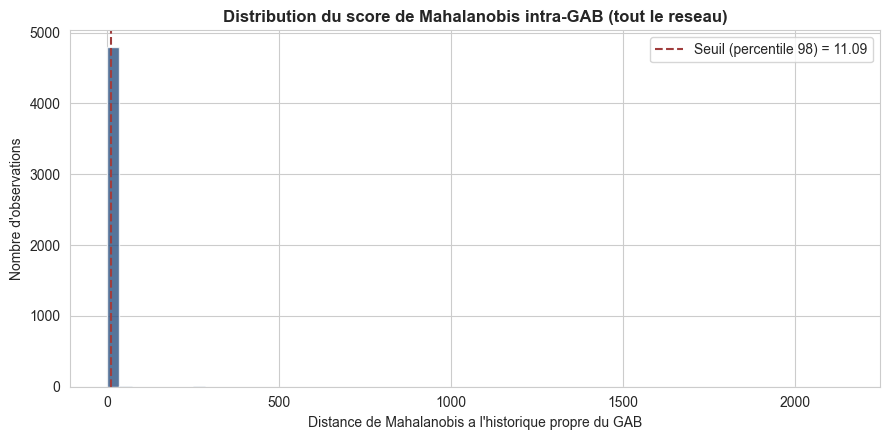

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Calibration du seuil Mahalanobis par percentile (taux d'alerte cible, pas un magic number)
# ══════════════════════════════════════════════════════════════════════════════
PCT_SEUIL_MAHALANOBIS = 98  # percentile - 2% des observations les plus extremes = alerte

scores_valides = df['mahalanobis_intra'].dropna()
SEUIL_MAHALANOBIS = np.percentile(scores_valides, PCT_SEUIL_MAHALANOBIS)

df['hors_norme_mahalanobis'] = df['mahalanobis_intra'] > SEUIL_MAHALANOBIS

print('Seuil Mahalanobis calibre au percentile {} : {:.2f}'.format(
    PCT_SEUIL_MAHALANOBIS, SEUIL_MAHALANOBIS))
print('Observations hors norme (score multivarie) : {:,} / {:,} ({:.1f}%)'.format(
    df['hors_norme_mahalanobis'].sum(), n_calcules,
    100 * df['hors_norme_mahalanobis'].sum() / n_calcules))

# Sanity check - comparaison avec l'ancienne approche par comptage de flags (partie 1B
# calculee plus bas) : combien d'observations "rupture systemique" (>=2 criteres) sont
# aussi captees par Mahalanobis, et inversement. Rappel a executer apres la cellule
# qui calcule statut_multi.
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(scores_valides, bins=60, color=COULEUR_NORMAL, alpha=0.8)
ax.axvline(SEUIL_MAHALANOBIS, color=COULEUR_RUPTURE, linestyle='--', linewidth=1.5,
           label='Seuil (percentile {}) = {:.2f}'.format(PCT_SEUIL_MAHALANOBIS, SEUIL_MAHALANOBIS))
ax.set_title('Distribution du score de Mahalanobis intra-GAB (tout le reseau)', fontweight='bold')
ax.set_xlabel('Distance de Mahalanobis a l\'historique propre du GAB')
ax.set_ylabel('Nombre d\'observations')
ax.legend()
plt.tight_layout()
plt.savefig('distribution_mahalanobis.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTIE 1A — Mono-critère

On prend **un seul critère à la fois** (paramètre `CRITERE_MONO`, ici `ret_pct_nuit`) et on
compare chaque GAB à sa propre trajectoire historique. Un GAB très nocturne depuis toujours
n'est pas un problème — un GAB qui **devient** nocturne récemment en est un.
---

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Z-score intra-GAB — critere mono-critere
# ══════════════════════════════════════════════════════════════════════════════
df = calculer_zscore_intra_gab(df, [CRITERE_MONO])

col_z_mono = 'zscore_intra_' + CRITERE_MONO
df['hors_norme_' + CRITERE_MONO] = df[col_z_mono].abs() > SEUIL_Z_RUPTURE

n_avec_historique = df[col_z_mono].notnull().sum()
print('Observations avec historique suffisant pour le z-score mono-critere : {:,} / {:,}'.format(
    n_avec_historique, len(df)))
print('Dont hors norme (|z| > {}) : {:,}'.format(
    SEUIL_Z_RUPTURE, df['hors_norme_' + CRITERE_MONO].sum()))

Observations avec historique suffisant pour le z-score mono-critere : 4,846 / 5,023
Dont hors norme (|z| > 2.0) : 755


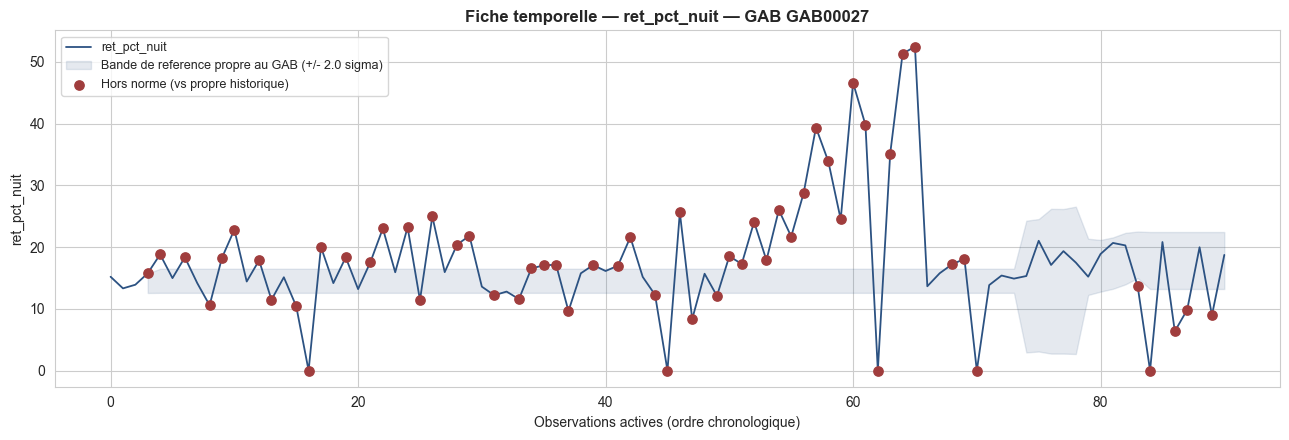

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Fiche temporelle d'un GAB — critere mono-critere, avec bande de reference PROPRE au GAB
# ══════════════════════════════════════════════════════════════════════════════
def tracer_fiche_mono_critere(df, gab_id, critere):
    sous_df = df[df['num_automate'] == gab_id].reset_index(drop=True)
    if len(sous_df) == 0:
        print('[ATTENTION] GAB "{}" introuvable.'.format(gab_id))
        return
    col_z = 'zscore_intra_' + critere
    col_moy = 'moy_roulante_' + critere
    col_std = 'std_roulante_' + critere

    fig, ax = plt.subplots(figsize=(13, 4.5))
    x = range(len(sous_df))
    ax.plot(x, sous_df[critere], '-', color=COULEUR_NORMAL, linewidth=1.3, label=critere)

    borne_haute = sous_df[col_moy] + SEUIL_Z_RUPTURE * sous_df[col_std]
    borne_basse = sous_df[col_moy] - SEUIL_Z_RUPTURE * sous_df[col_std]
    ax.fill_between(x, borne_basse, borne_haute, color=COULEUR_NORMAL, alpha=0.12,
                     label='Bande de reference propre au GAB (+/- {} sigma)'.format(SEUIL_Z_RUPTURE))

    hors_norme = sous_df[col_z].abs() > SEUIL_Z_RUPTURE
    if hors_norme.sum() > 0:
        ax.scatter(np.array(x)[hors_norme], sous_df.loc[hors_norme, critere],
                   color=COULEUR_RUPTURE, s=45, zorder=5, label='Hors norme (vs propre historique)')

    ax.set_title('Fiche temporelle — {} — GAB {}'.format(critere, gab_id), fontweight='bold')
    ax.set_xlabel('Observations actives (ordre chronologique)')
    ax.set_ylabel(critere)
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig('fiche_mono_critere_{}.png'.format(gab_id), dpi=150, bbox_inches='tight')
    plt.show()


# Exemple : GAB avec le plus grand nombre d'observations hors norme sur ce critere
gab_exemple = (df[df['hors_norme_' + CRITERE_MONO]]['num_automate']
               .value_counts().index[0] if df['hors_norme_' + CRITERE_MONO].sum() > 0
               else df['num_automate'].iloc[0])
tracer_fiche_mono_critere(df, gab_exemple, CRITERE_MONO)

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Tableau de synthese mono-critere — 1 ligne = 1 GAB
# ══════════════════════════════════════════════════════════════════════════════
synth_mono = df.dropna(subset=[col_z_mono]).groupby('num_automate').agg(
    n_observations   = (col_z_mono, 'count'),
    n_ruptures       = ('hors_norme_' + CRITERE_MONO, 'sum'),
    dernier_zscore   = (col_z_mono, 'last'),
).reset_index()
synth_mono['pct_ruptures'] = (synth_mono['n_ruptures'] / synth_mono['n_observations'] * 100).round(1)
synth_mono = synth_mono.sort_values('pct_ruptures', ascending=False).reset_index(drop=True)

print('Top 15 GAB — % d\'observations hors norme sur {} :'.format(CRITERE_MONO))
synth_mono.head(15)

Top 15 GAB — % d'observations hors norme sur ret_pct_nuit :


,num_automate,n_observations,n_ruptures,dernier_zscore,pct_ruptures
0,GAB00027,88,57,0.393235,64.8
1,GAB00009,106,47,0.384661,44.3
2,GAB00049,102,28,-1.104956,27.5
3,GAB00010,104,23,-0.124927,22.1
4,GAB00024,98,21,0.387078,21.4
5,GAB00023,104,21,0.504139,20.2
6,GAB00032,69,13,-0.732443,18.8
7,GAB00020,98,18,0.457767,18.4
8,GAB00034,93,17,-1.093964,18.3
9,GAB00053,68,12,-0.750504,17.6


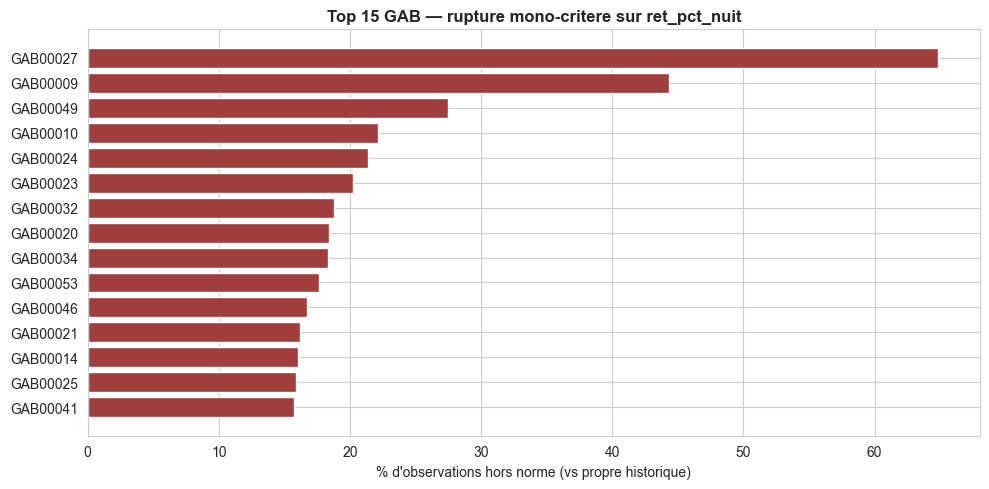

In [11]:
# ── Graphique — top GAB les plus en rupture sur ce critere ────────────────────
top15 = synth_mono.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top15['num_automate'][::-1], top15['pct_ruptures'][::-1], color=COULEUR_RUPTURE)
ax.set_xlabel('% d\'observations hors norme (vs propre historique)')
ax.set_title('Top 15 GAB — rupture mono-critere sur {}'.format(CRITERE_MONO), fontweight='bold')
plt.tight_layout()
plt.savefig('top15_mono_critere.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTIE 1B — Multi-critère

On empile plusieurs critères (`METRIQUES_MULTI`) et on regarde, **jour par jour et par GAB**,
combien de critères sont simultanément hors norme. C'est ce qui distingue un signal isolé
(1 critère bouge, souvent un pic ponctuel sans conséquence) d'un signal systémique (plusieurs
critères bougent ensemble, signe d'un vrai changement de profil du GAB).
---

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Z-scores intra-GAB — criteres multi-critere (detail par critere, pour l'explication)
# ══════════════════════════════════════════════════════════════════════════════
df = calculer_zscore_intra_gab(df, METRIQUES_MULTI)

cols_hors_norme = []
for m in METRIQUES_MULTI:
    col_hn = 'hors_norme_' + m
    df[col_hn] = df['zscore_intra_' + m].abs() > SEUIL_Z_RUPTURE
    cols_hors_norme.append(col_hn)

df['nb_criteres_hors_norme'] = df[cols_hors_norme].sum(axis=1)

# ── Statut multi-critere : base sur le score MULTIVARIE (Mahalanobis, section 4bis/4ter),
# pas sur le simple comptage de flags independants. Rationale : deux criteres fortement
# correles (ex. ret_pct_nuit et ret_pct_weekend qui bougent souvent ensemble) ne doivent
# pas etre comptes comme "2 signaux independants" - Mahalanobis le sait, un comptage naif
# ne le sait pas. `nb_criteres_hors_norme` reste calcule ci-dessus : il sert a EXPLIQUER
# quel(s) critere(s) sont en cause une fois qu'un GAB est repere comme en rupture, pas a
# decider de la severite.
conditions = [
    ~df['hors_norme_mahalanobis'].fillna(False),
    df['hors_norme_mahalanobis'].fillna(False) & (df['nb_criteres_hors_norme'] <= 1),
]
choix = ['stable', 'rupture isolee']
df['statut_multi'] = np.select(conditions, choix, default='rupture systemique')
df.loc[df['mahalanobis_intra'].isnull(), 'statut_multi'] = None

print('Repartition des observations par statut multi-critere (base Mahalanobis) :')
print(df['statut_multi'].value_counts(dropna=True))
print('\n(Base = observations disposant d\'un score de Mahalanobis, cf. section 4bis/4ter)')

# Sanity check : accord entre l'ancienne regle (comptage de flags >=2) et la nouvelle
# (Mahalanobis hors norme) - permet de voir concretement combien de cas changent de
# categorie et dans quel sens, avant de basculer definitivement le metier dessus.
ancien_systemique = df['nb_criteres_hors_norme'] >= 2
nouveau_systemique = df['statut_multi'] == 'rupture systemique'
accord = (ancien_systemique == nouveau_systemique).mean()
print('\nAccord ancien (comptage flags) vs nouveau (Mahalanobis) sur "systemique" : {:.1f}%'.format(
    100 * accord))
print('Cas systemiques avec l\'ancienne regle mais plus avec Mahalanobis (correles, pas independants) : {:,}'.format(
    (ancien_systemique & ~nouveau_systemique).sum()))
print('Cas systemiques avec Mahalanobis mais pas avec l\'ancienne regle (combinaison inedite non captee par les flags simples) : {:,}'.format(
    (~ancien_systemique & nouveau_systemique).sum()))

Repartition des observations par statut multi-critere (base Mahalanobis) :
statut_multi
stable                4751
rupture isolee          87
rupture systemique      10
Name: count, dtype: int64

(Base = observations disposant d'un score de Mahalanobis, cf. section 4bis/4ter)

Accord ancien (comptage flags) vs nouveau (Mahalanobis) sur "systemique" : 95.1%
Cas systemiques avec l'ancienne regle mais plus avec Mahalanobis (correles, pas independants) : 245
Cas systemiques avec Mahalanobis mais pas avec l'ancienne regle (combinaison inedite non captee par les flags simples) : 0


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Heatmap GAB x mois — intensite de rupture multi-critere (top GAB systemiques)
# ══════════════════════════════════════════════════════════════════════════════
top_gab_systemiques = (
    df[df['statut_multi'] == 'rupture systemique']['num_automate']
    .value_counts().head(20).index.tolist()
)

if len(top_gab_systemiques) > 0:
    pivot_heatmap = (
        df[df['num_automate'].isin(top_gab_systemiques)]
        .groupby(['num_automate', 'annee', 'mois'])['nb_criteres_hors_norme']
        .mean()
        .reset_index()
    )
    pivot_heatmap['periode'] = (
        pivot_heatmap['annee'].astype(str) + '-' + pivot_heatmap['mois'].astype(str).str.zfill(2)
    )
    tableau_pivot = pivot_heatmap.pivot(index='num_automate', columns='periode',
                                        values='nb_criteres_hors_norme')
    tableau_pivot.columns = tableau_pivot.columns.tolist()

    fig = go.Figure(data=go.Heatmap(
        z=tableau_pivot.values, x=tableau_pivot.columns, y=tableau_pivot.index,
        colorscale='Reds', colorbar=dict(title='Nb criteres\nhors norme (moy.)'),
    ))
    fig.update_layout(
        title='Intensite de rupture multi-critere — top 20 GAB systemiques',
        xaxis_title='Periode (annee-mois)', yaxis_title='GAB', height=600,
    )
    fig.show()
else:
    print('Aucun GAB en rupture systemique sur la periode disponible.')

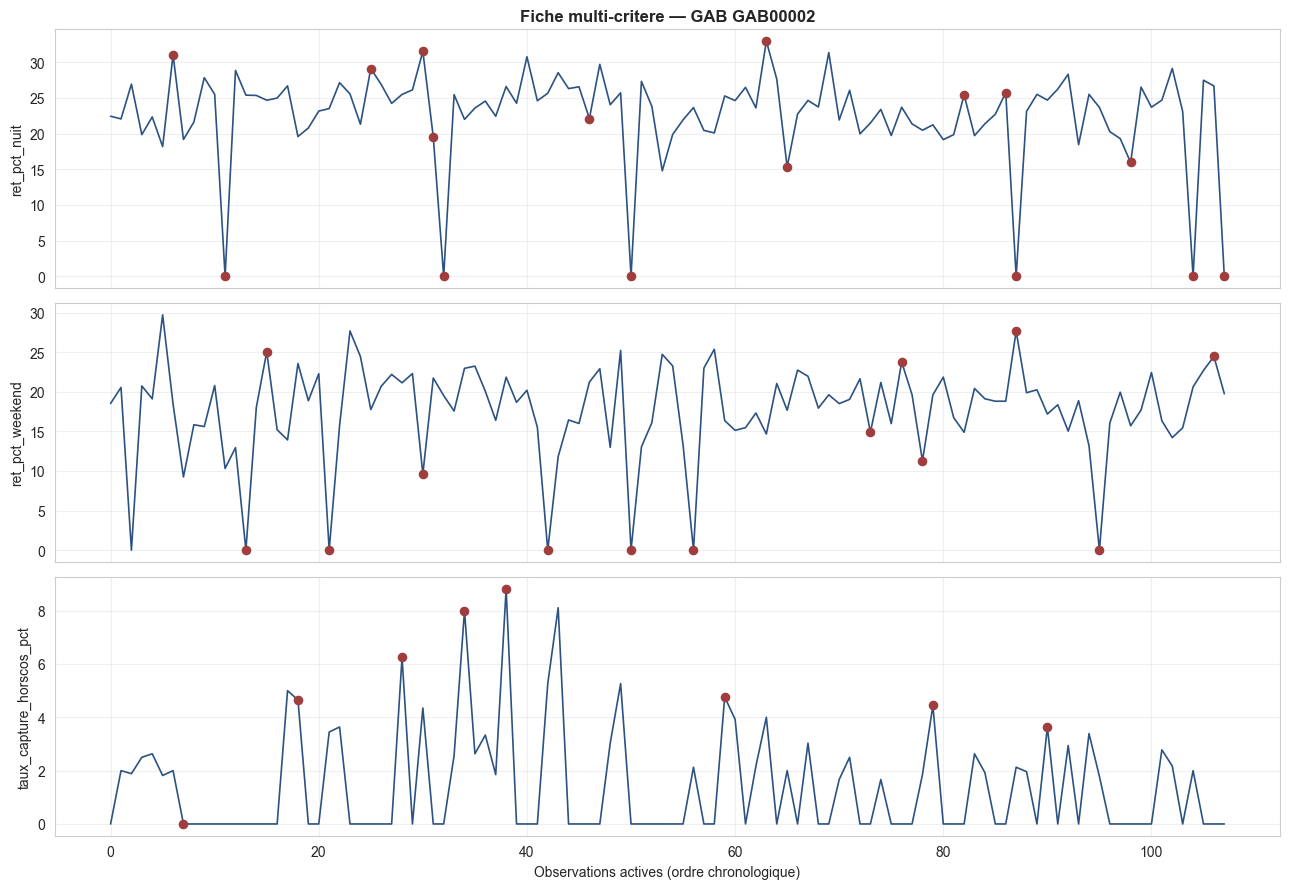

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Fiche multi-critere (petits multiples) pour un GAB donne
# ══════════════════════════════════════════════════════════════════════════════
def tracer_fiche_multi_critere(df, gab_id, criteres=METRIQUES_MULTI):
    sous_df = df[df['num_automate'] == gab_id].reset_index(drop=True)
    if len(sous_df) == 0:
        print('[ATTENTION] GAB "{}" introuvable.'.format(gab_id))
        return

    fig, axes = plt.subplots(len(criteres), 1, figsize=(13, 3 * len(criteres)), sharex=True)
    if len(criteres) == 1:
        axes = [axes]
    x = range(len(sous_df))

    for ax, critere in zip(axes, criteres):
        col_z = 'zscore_intra_' + critere
        ax.plot(x, sous_df[critere], '-', color=COULEUR_NORMAL, linewidth=1.2)
        hors_norme = sous_df[col_z].abs() > SEUIL_Z_RUPTURE
        if hors_norme.sum() > 0:
            ax.scatter(np.array(x)[hors_norme], sous_df.loc[hors_norme, critere],
                       color=COULEUR_RUPTURE, s=35, zorder=5)
        ax.set_ylabel(critere, fontsize=10)
        ax.grid(True, alpha=0.3)

    axes[0].set_title('Fiche multi-critere — GAB {}'.format(gab_id), fontweight='bold')
    axes[-1].set_xlabel('Observations actives (ordre chronologique)')
    plt.tight_layout()
    plt.savefig('fiche_multi_critere_{}.png'.format(gab_id), dpi=150, bbox_inches='tight')
    plt.show()


gab_exemple_multi = top_gab_systemiques[0] if len(top_gab_systemiques) > 0 else df['num_automate'].iloc[0]
tracer_fiche_multi_critere(df, gab_exemple_multi)

## 5. 📆 Agrégation mensuelle et dérive récurrente

Comme en v12 (section 10), l'agrégation se fait au niveau **mois** (pas de colonne date native).
On distingue un signal **ponctuel** (un mois isolé) d'une dérive **récurrente** — plusieurs mois
consécutifs avec au moins une observation en rupture systémique.

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Agregation jour -> mois, detection de derive recurrente
# ══════════════════════════════════════════════════════════════════════════════
# Note methodologique : la DUREE de la derive (3 mois consecutifs) est basee sur le
# comptage de criteres (nb_criteres_hors_norme >= 2), PAS sur le statut Mahalanobis.
# Raison empirique (verifiee sur ce dataset) : Mahalanobis, comme le z-score simple,
# "digere" un changement de regime en quelques observations (la fenetre glissante de
# reference integre vite le nouveau comportement et le score redescend) - il excelle a
# reperer LE MOMENT d'une rupture (pic net et bien plus eleve qu'un simple comptage),
# mais est plus bruite pour juger si la rupture TIENT dans la duree. Le comptage de
# criteres, plus grossier, s'avere plus stable pour cette question de duree. Le score
# Mahalanobis (section 4bis/4ter) reste utilise plus bas pour prioriser l'URGENCE des
# GAB une fois la derive recurrente identifiee.
agg_mois = df.groupby(['num_automate', 'annee', 'mois']).agg(
    nb_obs                = ('statut_multi', 'count'),
    nb_jours_isoles       = ('nb_criteres_hors_norme', lambda s: (s == 1).sum()),
    nb_jours_systemiques  = ('nb_criteres_hors_norme', lambda s: (s >= 2).sum()),
    mahalanobis_moyen_mois= ('mahalanobis_intra', 'mean'),
).reset_index()
agg_mois = agg_mois.sort_values(['num_automate', 'annee', 'mois']).reset_index(drop=True)
agg_mois['mois_systemique'] = agg_mois['nb_jours_systemiques'] > 0


def plus_longue_serie(series_bool):
    """Longueur de la plus longue serie de True consecutifs."""
    max_serie = 0
    courante = 0
    for v in series_bool:
        if v:
            courante += 1
            max_serie = max(max_serie, courante)
        else:
            courante = 0
    return max_serie


derive_recurrente = agg_mois.groupby('num_automate')['mois_systemique'].apply(plus_longue_serie)
derive_recurrente = derive_recurrente.reset_index(name='streak_max_mois_systemiques')
derive_recurrente['derive_recurrente'] = (
    derive_recurrente['streak_max_mois_systemiques'] >= SEUIL_STREAK_RECURRENT
)

print('GAB en derive recurrente (>= {} mois consecutifs en rupture systemique) : {}'.format(
    SEUIL_STREAK_RECURRENT, derive_recurrente['derive_recurrente'].sum()))
derive_recurrente[derive_recurrente['derive_recurrente']].sort_values(
    'streak_max_mois_systemiques', ascending=False)

GAB en derive recurrente (>= 3 mois consecutifs en rupture systemique) : 9


,num_automate,streak_max_mois_systemiques,derive_recurrente
19,GAB00020,5,True
8,GAB00009,4,True
26,GAB00027,4,True
16,GAB00017,3,True
9,GAB00010,3,True
23,GAB00024,3,True
49,GAB00050,3,True
55,GAB00056,3,True
57,GAB00058,3,True


## 5bis. 🔬 Explication par critère — pourquoi ce GAB dérive-t-il, et est-ce explicable ?

Le statut `stable` / `rupture isolee` / `rupture systemique` (partie 1B, désormais basé sur le
score multivarié Mahalanobis — section 4bis/4ter) et le statut `derive_recurrente` (ci-dessus)
disent **si** un GAB dérive, mais pas **sur quoi** ni **si c'est explicable**. Cette section
répond à trois questions :

1. **Quel critère domine** — quand plusieurs critères sont hors norme en même temps, ils ne
   pèsent pas tous pareil. Ils sont classés par **intensité de l'écart** (combien de fois le
   comportement pendant la dérive s'écarte de la bande habituelle du GAB), pas juste listés en
   vrac — le métier voit d'emblée lequel mérite l'attention en premier.
2. **Avec quelle valeur concrète** — la valeur réelle observée, la valeur de référence
   habituelle du GAB, et la valeur à la même période l'an dernier (effet saisonnier possible).
3. **Pour le critère "cartes clients avalées" spécifiquement, pour quelle raison** — le SQL
   source distingue le **motif** de chaque capture (oubli/incident lecteur, code confidentiel
   dépassé, carte perdue, carte volée, autre). Le motif dominant pendant la dérive est comparé
   au motif dominant habituel du GAB : un basculement (ex. de "oubli" vers "carte volée")
   pointe vers une cause bien plus précise qu'un simple pourcentage en hausse.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Detail par critere - classement par intensite + motif dominant de capture de carte
# ══════════════════════════════════════════════════════════════════════════════

# 1) Pct d'observations hors norme, par GAB et par critere (1 colonne par critere de
#    METRIQUES_MULTI) - permet de voir en un coup d'oeil lequel(s) critere(s) bougent.
detail_par_critere = df.groupby('num_automate').agg(
    **{'pct_hors_norme_' + m: ('hors_norme_' + m, 'mean') for m in METRIQUES_MULTI}
).reset_index()
for m in METRIQUES_MULTI:
    col = 'pct_hors_norme_' + m
    detail_par_critere[col] = (detail_par_critere[col] * 100).round(1)


def valeur_reference_meme_mois(df, gab, mois_cible, critere, annee_exclue):
    """Mediane/MAD du critere pour ce GAB, sur CE MEME MOIS CALENDAIRE (1-12), toutes
    annees disponibles SAUF celle de la derive en cours - c'est la reference
    saisonniere ('l'an dernier a la meme epoque, ce GAB faisait quoi ?'). Mediane/MAD
    plutot que moyenne/ecart-type : plus robuste aux outliers residuels du dataset
    (ex. un ratio explose ponctuellement quand son denominateur est tres faible un
    jour donne - une seule valeur aberrante ne doit pas fausser toute la reference)."""
    hist = df[(df['num_automate'] == gab) & (df['mois'] == mois_cible) &
              (df['annee'] != annee_exclue)][critere].dropna()
    if len(hist) < MIN_PERIODES_INTRA:
        return None, None, len(hist)
    mediane = hist.median()
    mad = (hist - mediane).abs().median() * 1.4826  # facteur de coherence avec l'ecart-type
    return mediane, mad, len(hist)


MOTIFS_CAPTURE = ['cap_nb_oubli_ou_incident_lecture', 'cap_nb_code_confidentiel_depasse',
                   'cap_nb_carte_perdue', 'cap_nb_carte_volee', 'cap_nb_autre_motif']
NOMS_MOTIFS_CLAIRS = {
    'cap_nb_oubli_ou_incident_lecture': 'Oubli / incident lecteur',
    'cap_nb_code_confidentiel_depasse': 'Code confidentiel depasse',
    'cap_nb_carte_perdue': 'Carte perdue',
    'cap_nb_carte_volee': 'Carte volee',
    'cap_nb_autre_motif': 'Autre motif',
}
MOTIFS_DISPONIBLES = [m for m in MOTIFS_CAPTURE if m in df.columns]


def motif_dominant(sous_df):
    """Motif de capture le plus frequent sur la sous-periode donnee, ou None si
    aucune donnee de motif disponible (colonnes absentes ou aucune capture)."""
    if not MOTIFS_DISPONIBLES:
        return None, None
    totaux = sous_df[MOTIFS_DISPONIBLES].sum()
    if totaux.sum() == 0:
        return None, None
    motif_code = totaux.idxmax()
    part_pct = round(totaux[motif_code] / totaux.sum() * 100, 1)
    return NOMS_MOTIFS_CLAIRS.get(motif_code, motif_code), part_pct


# 2) Pour les GAB en derive recurrente : quels criteres etaient hors norme pendant les
#    mois du streak retenu, avec valeur reelle, reference habituelle (bande intra-GAB),
#    reference saisonniere (meme mois, autres annees), et - pour le critere cartes
#    avalees - le motif dominant pendant la derive compare au motif dominant habituel.
gab_en_derive = derive_recurrente.loc[
    derive_recurrente['derive_recurrente'], 'num_automate'].tolist()

lignes_explication = []
for gab in gab_en_derive:
    sous_agg = agg_mois[agg_mois['num_automate'] == gab].reset_index(drop=True)
    meilleure_serie, serie_courante = [], []
    for _, ligne in sous_agg.iterrows():
        if ligne['mois_systemique']:
            serie_courante.append((ligne['annee'], ligne['mois']))
            if len(serie_courante) > len(meilleure_serie):
                meilleure_serie = serie_courante.copy()
        else:
            serie_courante = []

    sous_df = df[(df['num_automate'] == gab) &
                 (df[['annee', 'mois']].apply(tuple, axis=1).isin(meilleure_serie))]
    hors_derive_df = df[(df['num_automate'] == gab) &
                        (~df[['annee', 'mois']].apply(tuple, axis=1).isin(meilleure_serie))]
    periode_txt = '{}-{:02d} a {}-{:02d}'.format(
        meilleure_serie[0][0], meilleure_serie[0][1],
        meilleure_serie[-1][0], meilleure_serie[-1][1]) if meilleure_serie else ''
    nb_cartes_avalees_periode = int(sous_df['cap_nb'].sum())

    motif_pendant, part_motif_pendant = motif_dominant(sous_df)
    motif_habituel, part_motif_habituel = motif_dominant(hors_derive_df)
    motif_a_change = (
        motif_pendant is not None and motif_habituel is not None
        and motif_pendant != motif_habituel
    )

    ecarts_par_critere = []
    for m in METRIQUES_MULTI:
        obs_hors_norme = sous_df[sous_df['hors_norme_' + m]]
        if len(obs_hors_norme) == 0:
            continue
        valeur_pendant_derive = obs_hors_norme[m].mean()
        ref_habituelle = sous_df['moy_roulante_' + m].mean()
        ref_habituelle_std = sous_df['std_roulante_' + m].mean()

        refs_saison = [
            valeur_reference_meme_mois(df, gab, mo, m, annee_exclue=a)
            for a, mo in meilleure_serie
        ]
        medianes_saison = [r[0] for r in refs_saison if r[0] is not None]
        mads_saison = [r[1] for r in refs_saison if r[1] is not None]
        n_obs_saison = sum(r[2] for r in refs_saison)

        deja_vu = False
        if medianes_saison and mads_saison:
            mediane_saison = np.median(medianes_saison)
            mad_saison = np.median(mads_saison) if np.median(mads_saison) > 0 else np.nan
            if not np.isnan(mad_saison):
                z_saison = abs(valeur_pendant_derive - mediane_saison) / mad_saison
                deja_vu = z_saison <= SEUIL_Z_RUPTURE

        # Intensite de l'ecart : combien de fois la valeur pendant la derive s'ecarte
        # de la bande habituelle du GAB, en unites d'ecart-type - permet de CLASSER
        # les criteres par ordre d'importance plutot que de les lister en vrac (un
        # ecart de 0.3 sigma et un ecart de 8 sigma ne meritent pas la meme attention
        # meme s'ils sont tous les deux "hors norme").
        if pd.notnull(ref_habituelle) and pd.notnull(ref_habituelle_std) and ref_habituelle_std > 0:
            intensite_ecart = abs(valeur_pendant_derive - ref_habituelle) / ref_habituelle_std
        else:
            intensite_ecart = np.nan

        ligne = {
            'num_automate': gab,
            'periode_derive': periode_txt,
            'critere': m,
            'valeur_pendant_derive': round(valeur_pendant_derive, 2),
            'valeur_habituelle_gab': round(ref_habituelle, 2) if pd.notnull(ref_habituelle) else None,
            'ecart_type_habituel_gab': round(ref_habituelle_std, 2) if pd.notnull(ref_habituelle_std) else None,
            'intensite_ecart_sigma': round(intensite_ecart, 1) if pd.notnull(intensite_ecart) else None,
            'valeur_meme_mois_autres_annees': round(np.median(medianes_saison), 2) if medianes_saison else None,
            'n_observations_ref_saisonniere': n_obs_saison,
            'deja_vu_meme_periode': deja_vu,
            'nb_cartes_hors_cos_avalees_periode': nb_cartes_avalees_periode,
        }
        if m == 'taux_capture_horscos_pct':
            ligne['motif_dominant_pendant_derive'] = motif_pendant
            ligne['part_motif_dominant_pendant_pct'] = part_motif_pendant
            ligne['motif_dominant_habituel'] = motif_habituel
            ligne['part_motif_dominant_habituel_pct'] = part_motif_habituel
            ligne['motif_a_change'] = motif_a_change
        ecarts_par_critere.append(ligne)

    # Classement par intensite decroissante - le critere le plus marque en premier
    ecarts_par_critere.sort(
        key=lambda l: l['intensite_ecart_sigma'] if l['intensite_ecart_sigma'] is not None else -1,
        reverse=True)
    lignes_explication.extend(ecarts_par_critere)

COLONNES_DETAIL = [
    'num_automate', 'periode_derive', 'critere', 'intensite_ecart_sigma',
    'valeur_pendant_derive', 'valeur_habituelle_gab', 'ecart_type_habituel_gab',
    'valeur_meme_mois_autres_annees', 'n_observations_ref_saisonniere', 'deja_vu_meme_periode',
    'nb_cartes_hors_cos_avalees_periode', 'motif_dominant_pendant_derive',
    'part_motif_dominant_pendant_pct', 'motif_dominant_habituel',
    'part_motif_dominant_habituel_pct', 'motif_a_change']
detail_criteres_derive = pd.DataFrame(lignes_explication, columns=COLONNES_DETAIL)

# 3) Vue compacte 1 ligne = 1 GAB (criteres_responsables classes par intensite +
#    alerte saisonniere + alerte de changement de motif) pour le dashboard / la carte.
if len(detail_criteres_derive) > 0:
    def _criteres_classes(sous):
        return ', '.join(sous.sort_values('intensite_ecart_sigma', ascending=False)['critere'])

    resume_par_gab = detail_criteres_derive.groupby('num_automate').apply(
        lambda g: pd.Series({
            'criteres_responsables': _criteres_classes(g),
            'critere_dominant': g.sort_values('intensite_ecart_sigma', ascending=False)['critere'].iloc[0],
            'tous_deja_vu_meme_periode': g['deja_vu_meme_periode'].all(),
            'au_moins_un_deja_vu': g['deja_vu_meme_periode'].any(),
            'nb_cartes_hors_cos_avalees_periode': g['nb_cartes_hors_cos_avalees_periode'].iloc[0],
            'motif_a_change_capture': bool(g['motif_a_change'].any()) if 'motif_a_change' in g else False,
        })
    ).reset_index()
    periode_par_gab = detail_criteres_derive[['num_automate', 'periode_derive']].drop_duplicates()
    resume_par_gab = resume_par_gab.merge(periode_par_gab, on='num_automate', how='left')
else:
    resume_par_gab = pd.DataFrame(columns=[
        'num_automate', 'criteres_responsables', 'critere_dominant',
        'tous_deja_vu_meme_periode', 'au_moins_un_deja_vu',
        'nb_cartes_hors_cos_avalees_periode', 'motif_a_change_capture', 'periode_derive'])

# 4) Assemblage - table 1 ligne = 1 GAB a transmettre au metier pour verification manuelle
tableau_explicatif = (
    detail_par_critere
    .merge(derive_recurrente[['num_automate', 'streak_max_mois_systemiques', 'derive_recurrente']],
           on='num_automate', how='left')
    .merge(resume_par_gab, on='num_automate', how='left')
)
tableau_explicatif['periode_derive'] = tableau_explicatif['periode_derive'].fillna('')
tableau_explicatif['criteres_responsables'] = tableau_explicatif['criteres_responsables'].fillna('')
tableau_explicatif = tableau_explicatif.sort_values(
    ['derive_recurrente', 'streak_max_mois_systemiques'], ascending=[False, False]
).reset_index(drop=True)

print('Tableau explicatif (1 ligne = 1 GAB) : {} GAB | {} en derive recurrente'.format(
    len(tableau_explicatif), tableau_explicatif['derive_recurrente'].sum()))
if MOTIFS_DISPONIBLES:
    n_motif_change = tableau_explicatif['motif_a_change_capture'].fillna(False).sum()
    print('Dont {} GAB ou le motif dominant de capture a change pendant la derive '
          '(signal de cause potentiellement precise, ex: bascule vers "carte volee").'.format(n_motif_change))
tableau_explicatif

Tableau explicatif (1 ligne = 1 GAB) : 59 GAB | 9 en derive recurrente
Dont 1 GAB ou le motif dominant de capture a change pendant la derive (signal de cause potentiellement precise, ex: bascule vers "carte volee").


,num_automate,pct_hors_norme_ret_pct_nuit,pct_hors_norme_ret_pct_weekend,pct_hors_norme_taux_capture_horscos_pct,streak_max_mois_systemiques,derive_recurrente,criteres_responsables,critere_dominant,tous_deja_vu_meme_periode,au_moins_un_deja_vu,nb_cartes_hors_cos_avalees_periode,motif_a_change_capture,periode_derive
0,GAB00020,17.8,41.6,7.9,5,True,"ret_pct_weekend, taux_capture_horscos_pct, ret...",ret_pct_weekend,False,True,17.0,False,2025-06 a 2025-10
1,GAB00009,43.1,11.9,10.1,4,True,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,False,True,8.0,False,2025-12 a 2026-03
2,GAB00027,62.6,12.1,17.6,4,True,"ret_pct_nuit, taux_capture_horscos_pct, ret_pc...",ret_pct_nuit,False,False,41.0,False,2025-11 a 2026-02
3,GAB00010,21.5,14.0,12.1,3,True,"ret_pct_nuit, ret_pct_weekend, taux_capture_ho...",ret_pct_nuit,True,True,12.0,False,2024-12 a 2025-02
4,GAB00017,14.1,16.9,12.7,3,True,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,False,True,15.0,False,2024-02 a 2024-04
5,GAB00024,20.8,16.8,8.9,3,True,"ret_pct_nuit, ret_pct_weekend, taux_capture_ho...",ret_pct_nuit,False,False,30.0,False,2024-11 a 2025-01
6,GAB00050,10.5,14.3,7.6,3,True,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,False,True,7.0,True,2026-02 a 2026-04
7,GAB00056,10.8,21.6,12.7,3,True,"ret_pct_weekend, ret_pct_nuit, taux_capture_ho...",ret_pct_weekend,False,True,10.0,False,2026-03 a 2026-05
8,GAB00058,11.9,12.8,14.7,3,True,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,False,True,5.0,False,2024-07 a 2024-09
9,GAB00000,12.7,11.4,57.0,2,False,,NaN,NaN,NaN,NaN,NaN,


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Detail complet critere par critere - classe par intensite, avec motif de capture
# ══════════════════════════════════════════════════════════════════════════════
print('Detail par GAB x critere (uniquement les GAB en derive recurrente),')
print('classe du critere le PLUS marque au moins marque (intensite_ecart_sigma) :')
print('- intensite_ecart_sigma : combien de fois la valeur pendant la derive s\'ecarte de la')
print('  bande habituelle du GAB, en unites d\'ecart-type - plus c\'est eleve, plus ca merite')
print('  l\'attention en premier parmi les criteres en cause pour ce GAB.')
print('- valeur_pendant_derive / valeur_habituelle_gab : valeur reelle vs bande de reference du GAB.')
print('- valeur_meme_mois_autres_annees : meme mois calendaire, autres annees (saisonnalite).')
print('- deja_vu_meme_periode : la valeur actuelle est dans la bande saisonniere -> a verifier')
print('  avant de traiter comme anomalie (peut etre un effet fetes/vacances recurrent).')
print('- motif_dominant_pendant_derive / motif_dominant_habituel (critere cartes clients')
print('  avalees uniquement) : le motif de capture le plus frequent pendant la derive, compare')
print('  au motif habituel du GAB - un changement de motif (motif_a_change=True) pointe vers')
print('  une cause plus precise qu\'un simple pourcentage en hausse (ex: bascule vers "carte')
print('  volee" plutot que le classique "oubli / incident lecteur").\n')

detail_criteres_derive.sort_values(
    ['num_automate', 'intensite_ecart_sigma'], ascending=[True, False]
).reset_index(drop=True)

Detail par GAB x critere (uniquement les GAB en derive recurrente),
classe du critere le PLUS marque au moins marque (intensite_ecart_sigma) :
- intensite_ecart_sigma : combien de fois la valeur pendant la derive s'ecarte de la
  bande habituelle du GAB, en unites d'ecart-type - plus c'est eleve, plus ca merite
  l'attention en premier parmi les criteres en cause pour ce GAB.
- valeur_pendant_derive / valeur_habituelle_gab : valeur reelle vs bande de reference du GAB.
- valeur_meme_mois_autres_annees : meme mois calendaire, autres annees (saisonnalite).
- deja_vu_meme_periode : la valeur actuelle est dans la bande saisonniere -> a verifier
  avant de traiter comme anomalie (peut etre un effet fetes/vacances recurrent).
- motif_dominant_pendant_derive / motif_dominant_habituel (critere cartes clients
  avalees uniquement) : le motif de capture le plus frequent pendant la derive, compare
  au motif habituel du GAB - un changement de motif (motif_a_change=True) pointe vers
  une cause plu

,num_automate,periode_derive,critere,intensite_ecart_sigma,valeur_pendant_derive,valeur_habituelle_gab,ecart_type_habituel_gab,valeur_meme_mois_autres_annees,n_observations_ref_saisonniere,deja_vu_meme_periode,nb_cartes_hors_cos_avalees_periode,motif_dominant_pendant_derive,part_motif_dominant_pendant_pct,motif_dominant_habituel,part_motif_dominant_habituel_pct,motif_a_change
0,GAB00009,2025-12 a 2026-03,taux_capture_horscos_pct,3.0,5.05,1.19,1.28,1.29,26,False,8,Oubli / incident lecteur,50.0,Oubli / incident lecteur,53.7,False
1,GAB00009,2025-12 a 2026-03,ret_pct_nuit,1.9,22.67,20.59,1.10,20.29,26,True,8,NaN,NaN,NaN,NaN,NaN
2,GAB00009,2025-12 a 2026-03,ret_pct_weekend,1.4,12.23,18.13,4.35,18.71,26,True,8,NaN,NaN,NaN,NaN,NaN
3,GAB00010,2024-12 a 2025-02,ret_pct_nuit,1.6,12.81,17.18,2.78,15.03,14,True,12,NaN,NaN,NaN,NaN,NaN
4,GAB00010,2024-12 a 2025-02,ret_pct_weekend,1.0,6.50,11.02,4.46,11.46,14,True,12,NaN,NaN,NaN,NaN,NaN
5,GAB00010,2024-12 a 2025-02,taux_capture_horscos_pct,0.9,3.27,1.96,1.52,2.08,14,True,12,Oubli / incident lecteur,66.7,Oubli / incident lecteur,54.8,False
6,GAB00017,2024-02 a 2024-04,taux_capture_horscos_pct,1.9,0.00,2.77,1.48,0.00,8,False,15,Oubli / incident lecteur,73.3,Oubli / incident lecteur,47.8,False
7,GAB00017,2024-02 a 2024-04,ret_pct_nuit,0.7,8.78,10.65,2.50,10.34,8,False,15,NaN,NaN,NaN,NaN,NaN
8,GAB00017,2024-02 a 2024-04,ret_pct_weekend,0.1,18.18,18.31,1.94,17.55,8,True,15,NaN,NaN,NaN,NaN,NaN
9,GAB00020,2025-06 a 2025-10,ret_pct_weekend,5.7,15.87,22.05,1.09,20.02,31,True,17,NaN,NaN,NaN,NaN,NaN


## 6. 🔎 Tableau de bord de synthèse — Vision 1

**1 ligne = 1 GAB** : statut mono-critère (sur `CRITERE_MONO`), statut multi-critère dominant,
et statut de dérive récurrente. C'est la table à transmettre au métier pour investigation.

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Dashboard de synthese — 1 ligne = 1 GAB
# ══════════════════════════════════════════════════════════════════════════════
synth_multi = df.groupby('num_automate').agg(
    n_obs_multi           = ('statut_multi', 'count'),
    n_ruptures_isolees    = ('statut_multi', lambda s: (s == 'rupture isolee').sum()),
    n_ruptures_systemiques= ('statut_multi', lambda s: (s == 'rupture systemique').sum()),
    score_mahalanobis_moyen = ('mahalanobis_intra', 'mean'),
    score_mahalanobis_max   = ('mahalanobis_intra', 'max'),
).reset_index()
synth_multi['pct_systemique'] = (
    synth_multi['n_ruptures_systemiques'] / synth_multi['n_obs_multi'] * 100
).round(1)
synth_multi['score_mahalanobis_moyen'] = synth_multi['score_mahalanobis_moyen'].round(2)
synth_multi['score_mahalanobis_max'] = synth_multi['score_mahalanobis_max'].round(2)

dashboard_vision1 = (
    df[['num_automate', 'code_postale_emplacement', 'longitude', 'latitude']]
    .drop_duplicates('num_automate')
    .merge(synth_mono[['num_automate', 'pct_ruptures']].rename(
        columns={'pct_ruptures': 'pct_ruptures_mono_' + CRITERE_MONO}), on='num_automate', how='left')
    .merge(synth_multi[['num_automate', 'pct_systemique', 'n_ruptures_systemiques',
                         'score_mahalanobis_moyen', 'score_mahalanobis_max']],
           on='num_automate', how='left')
    .merge(derive_recurrente[['num_automate', 'streak_max_mois_systemiques', 'derive_recurrente']],
           on='num_automate', how='left')
    .merge(tableau_explicatif[['num_automate', 'periode_derive', 'criteres_responsables',
                                'critere_dominant', 'au_moins_un_deja_vu', 'tous_deja_vu_meme_periode',
                                'nb_cartes_hors_cos_avalees_periode', 'motif_a_change_capture']],
           on='num_automate', how='left')
)
dashboard_vision1['criteres_responsables'] = dashboard_vision1['criteres_responsables'].fillna('')
dashboard_vision1['critere_dominant'] = dashboard_vision1['critere_dominant'].fillna('')
dashboard_vision1['periode_derive'] = dashboard_vision1['periode_derive'].fillna('')

# BUG CORRIGE : apres un merge 'how=left', une colonne booleenne qui contient des NaN
# (GAB absents de la table de droite) passe en dtype 'object' (melange bool/NaN), PAS
# en dtype bool. .fillna(False) seul NE SUFFIT PAS a revenir a un vrai bool ndarray -
# la colonne reste 'object'. np.select() exige un bool ndarray strict et plante alors
# avec "TypeError: invalid entry in condlist: should be boolean ndarray". Le fix est
# .fillna(False).astype(bool) explicitement sur CHAQUE colonne booleenne issue d'un merge.
for col_bool in ['motif_a_change_capture', 'derive_recurrente', 'au_moins_un_deja_vu',
                 'tous_deja_vu_meme_periode']:
    if col_bool in dashboard_vision1.columns:
        dashboard_vision1[col_bool] = dashboard_vision1[col_bool].fillna(False).astype(bool)

# Categorie a 3 niveaux pour le metier : stable / a verifier (saisonnier possible) /
# a investiguer (aucune explication saisonniere trouvee sur les criteres en cause).
dashboard_vision1['categorie_metier'] = np.select(
    [
        ~dashboard_vision1['derive_recurrente'].fillna(False),
        dashboard_vision1['au_moins_un_deja_vu'].fillna(False),
    ],
    ['Stable / ponctuel', 'Derive recurrente - saisonnalite possible (a verifier)'],
    default='Derive recurrente - a investiguer',
)

# Tri par IMPACT CLIENT REEL (volume de cartes avalees hors-COS) plutot que par
# score statistique seul - c'est le chiffre qui compte le plus pour prioriser une
# intervention terrain, un score eleve sur peu de cartes reelles est moins urgent
# qu'un volume important meme avec un score plus modere.
dashboard_vision1 = dashboard_vision1.sort_values(
    ['derive_recurrente', 'nb_cartes_hors_cos_avalees_periode'],
    ascending=[False, False], na_position='last'
).reset_index(drop=True)

print('Dashboard vision 1 : {} GAB'.format(len(dashboard_vision1)))
print(dashboard_vision1['categorie_metier'].value_counts())
dashboard_vision1.head(20)

Dashboard vision 1 : 59 GAB
categorie_metier
Stable / ponctuel                                         50
Derive recurrente - saisonnalite possible (a verifier)     7
Derive recurrente - a investiguer                          2
Name: count, dtype: int64


,num_automate,code_postale_emplacement,longitude,latitude,pct_ruptures_mono_ret_pct_nuit,pct_systemique,n_ruptures_systemiques,score_mahalanobis_moyen,score_mahalanobis_max,streak_max_mois_systemiques,derive_recurrente,periode_derive,criteres_responsables,critere_dominant,au_moins_un_deja_vu,tous_deja_vu_meme_periode,nb_cartes_hors_cos_avalees_periode,motif_a_change_capture,categorie_metier
0,GAB00027,15960.0,3.752477,43.692365,64.8,0.0,0,8.48,529.29,4,True,2025-11 a 2026-02,"ret_pct_nuit, taux_capture_horscos_pct, ret_pc...",ret_pct_nuit,False,False,41.0,False,Derive recurrente - a investiguer
1,GAB00024,24814.0,0.892523,49.331225,21.4,0.0,0,2.56,33.24,3,True,2024-11 a 2025-01,"ret_pct_nuit, ret_pct_weekend, taux_capture_ho...",ret_pct_nuit,False,False,30.0,False,Derive recurrente - a investiguer
2,GAB00020,43578.0,-1.901991,49.438328,18.4,0.0,0,10.56,801.78,5,True,2025-06 a 2025-10,"ret_pct_weekend, taux_capture_horscos_pct, ret...",ret_pct_weekend,True,False,17.0,False,Derive recurrente - saisonnalite possible (a v...
3,GAB00017,74448.0,5.328211,46.485360,14.7,1.5,1,2.56,23.69,3,True,2024-02 a 2024-04,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,True,False,15.0,False,Derive recurrente - saisonnalite possible (a v...
4,GAB00010,62710.0,-0.103095,50.778449,22.1,0.0,0,2.37,11.09,3,True,2024-12 a 2025-02,"ret_pct_nuit, ret_pct_weekend, taux_capture_ho...",ret_pct_nuit,True,True,12.0,False,Derive recurrente - saisonnalite possible (a v...
5,GAB00056,41754.0,5.494481,43.749767,11.1,1.0,1,11.17,866.36,3,True,2026-03 a 2026-05,"ret_pct_weekend, ret_pct_nuit, taux_capture_ho...",ret_pct_weekend,True,False,10.0,False,Derive recurrente - saisonnalite possible (a v...
6,GAB00009,22046.0,-0.963903,45.873632,44.3,0.0,0,3.69,126.85,4,True,2025-12 a 2026-03,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,True,False,8.0,False,Derive recurrente - saisonnalite possible (a v...
7,GAB00050,39448.0,5.231690,45.575834,10.8,0.0,0,2.17,7.02,3,True,2026-02 a 2026-04,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,True,False,7.0,True,Derive recurrente - saisonnalite possible (a v...
8,GAB00058,48363.0,5.311914,47.609194,12.3,0.9,1,9.68,369.10,3,True,2024-07 a 2024-09,"taux_capture_horscos_pct, ret_pct_nuit, ret_pc...",taux_capture_horscos_pct,True,False,5.0,False,Derive recurrente - saisonnalite possible (a v...
9,GAB00000,79330.0,-1.631926,43.158930,13.2,0.0,0,2.62,10.78,2,False,,,,NaN,NaN,NaN,False,Stable / ponctuel


## 6bis. 📋 Tableau pour le métier — sans jargon statistique

Le dashboard ci-dessus utilise des noms de colonnes techniques (`mahalanobis_intra`,
`streak_max_mois_systemiques`...) nécessaires pour le code, mais illisibles pour quelqu'un qui
ne fait pas de data science. Cette section produit la **même information**, avec des noms de
colonnes en français clair — c'est cette version qui doit être montrée ou exportée pour les
équipes métier, pas le dashboard technique ci-dessus.

**Ce qui passe en premier : le nombre réel de cartes clients avalées**, pas un pourcentage
abstrait — un taux de 12% ne dit rien tant qu'on ne sait pas si ça représente 2 cartes ou 40
cartes sur la période. Le classement du tableau se fait sur ce volume, pas sur un score
statistique : un score élevé sur peu de cartes réelles est moins urgent qu'un volume important.

**Cartes COS exclues du calcul.** Les cartes avalées sur un automate "COS" (compte/carte
internes, hors clientèle classique) sont normales et attendues — ce ne sont pas des incidents à
remonter. Seules les cartes de clients "classiques" avalées comptent ici : c'est le vrai signal
d'un problème (lecteur défaillant, tentative de fraude, ergonomie...).

| Colonne technique | Colonne métier | Ce que ça veut dire |
|---|---|---|
| `nb_cartes_hors_cos_avalees_periode` | Cartes clients avalées | Le nombre réel de cartes de clients (hors COS) avalées pendant la période de dérive — le chiffre le plus concret pour juger de l'ampleur. |
| `score_mahalanobis_max` | Score d'anomalie (pic le plus fort) | Plus le chiffre est élevé, plus le comportement du GAB ce jour-là s'écarte de son propre historique. Sert à confirmer/prioriser, pas à décider seul. |
| `streak_max_mois_systemiques` | Nombre de mois consécutifs en dérive | Combien de mois d'affilée le GAB a montré un changement de comportement sur plusieurs critères à la fois. |
| `criteres_responsables` | Critère(s) à l'origine de la dérive | Sur quoi porte le changement : les retraits de nuit, le week-end, les cartes clients avalées — ou une combinaison. |
| `au_moins_un_deja_vu` | Explicable par la saison ? | Si le même comportement s'est déjà produit à la même période les années précédentes (ex. vacances, fêtes) — un signal à vérifier avant de le traiter comme un problème. |

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Version du dashboard destinee au metier - noms de colonnes en francais clair
# ══════════════════════════════════════════════════════════════════════════════
NOMS_CRITERE_SEUL_CLAIRS = {
    '': '-', 'ret_pct_nuit': 'Retraits de nuit', 'ret_pct_weekend': 'Retraits le week-end',
    'taux_capture_horscos_pct': 'Cartes clients avalees',
}
NOMS_SITUATION_CLAIRS = {'Stable / ponctuel': 'Stable', 'Derive recurrente - saisonnalite possible (a verifier)': 'A verifier (explication saisonniere possible)', 'Derive recurrente - a investiguer': 'A investiguer en priorite'}


def traduire_liste_criteres(criteres_txt):
    """Traduit chaque critere de la liste (deja triee par intensite decroissante en
    amont, donc l'ordre du texte a du sens : le premier cite est le plus marque) -
    terme par terme plutot qu'une correspondance de chaine complete, robuste a
    n'importe quel ordre ou nombre de criteres."""
    if not criteres_txt:
        return '-'
    codes = [c.strip() for c in criteres_txt.split(',')]
    return ' > '.join(NOMS_CRITERE_SEUL_CLAIRS.get(c, c) for c in codes)


dashboard_metier = dashboard_vision1.copy()
dashboard_metier["Critere dominant"] = dashboard_metier['critere_dominant'].map(
    NOMS_CRITERE_SEUL_CLAIRS).fillna(dashboard_metier['critere_dominant'])
dashboard_metier["Tous les criteres en cause (du plus au moins marque)"] = (
    dashboard_metier['criteres_responsables'].apply(traduire_liste_criteres)
)
dashboard_metier['Situation'] = dashboard_metier['categorie_metier'].map(NOMS_SITUATION_CLAIRS)

# Le nombre de cartes et le score d'anomalie n'ont de sens actionnable que pour les
# GAB effectivement en derive recurrente - pour un GAB stable, un pic isole sur une
# seule journee peut produire un chiffre eleve sans que ca traduise un vrai probleme.
en_derive = dashboard_metier['derive_recurrente'].fillna(False)
dashboard_metier['Cartes clients avalees (sur la periode de derive)'] = np.where(
    en_derive, dashboard_metier['nb_cartes_hors_cos_avalees_periode'], np.nan)
dashboard_metier["Score d'anomalie (pic le plus fort observe)"] = np.where(
    en_derive, dashboard_metier['score_mahalanobis_max'].round(1), np.nan)
# Signal specifique : le motif dominant de capture de carte a-t-il change pendant la
# derive (ex: bascule de "oubli / incident lecteur" vers "carte volee") - une piste
# de cause plus precise qu'un simple pourcentage de cartes avalees en hausse. Affiche
# uniquement quand le critere "cartes clients avalees" fait partie de la derive.
dashboard_metier["Motif de capture different de l\'habitude"] = np.where(
    en_derive, dashboard_metier['motif_a_change_capture'].map({True: 'Oui - a investiguer', False: 'Non'}), '-')

dashboard_metier['Deja observe a la meme periode les annees precedentes'] = (
    dashboard_metier['au_moins_un_deja_vu']
    .map({True: 'Oui', False: 'Non'})
    .fillna('-')
)

dashboard_metier = dashboard_metier.rename(columns={
    'num_automate': 'Distributeur (GAB)',
    'code_postale_emplacement': 'Code postal',
    'streak_max_mois_systemiques': 'Nombre de mois consecutifs en derive',
    'periode_derive': 'Periode de la derive',
})
dashboard_metier['Nombre de mois consecutifs en derive'] = np.where(
    en_derive, dashboard_metier['Nombre de mois consecutifs en derive'], 0)
dashboard_metier['Periode de la derive'] = dashboard_metier['Periode de la derive'].replace('', '-')

# Ordre des colonnes : le volume de cartes clients avalees et le critere DOMINANT en
# premier - le detail complet (tous les criteres, tries du plus au moins marque) et le
# motif de capture restent disponibles juste apres pour qui veut approfondir, sans
# surcharger la premiere lecture.
COLONNES_AFFICHEES = [
    'Distributeur (GAB)', 'Code postal', 'Situation',
    'Cartes clients avalees (sur la periode de derive)',
    "Score d'anomalie (pic le plus fort observe)", 'Nombre de mois consecutifs en derive',
    'Critere dominant', 'Tous les criteres en cause (du plus au moins marque)',
    "Motif de capture different de l\'habitude", 'Periode de la derive',
    'Deja observe a la meme periode les annees precedentes',
]

pd.set_option('display.max_colwidth', 60)
print("Tableau destine au metier - a utiliser pour la lecture / l'export, pas le dashboard technique ci-dessus.")
print("Trie par nombre de cartes clients avalees (le plus concret pour prioriser une intervention).")
dashboard_metier[COLONNES_AFFICHEES].head(20)

Tableau destine au metier - a utiliser pour la lecture / l'export, pas le dashboard technique ci-dessus.
Trie par nombre de cartes clients avalees (le plus concret pour prioriser une intervention).


,Distributeur (GAB),Code postal,Situation,Cartes clients avalees (sur la periode de derive),Score d'anomalie (pic le plus fort observe),Nombre de mois consecutifs en derive,Critere dominant,Tous les criteres en cause (du plus au moins marque),Motif de capture different de l'habitude,Periode de la derive,Deja observe a la meme periode les annees precedentes
0,GAB00027,15960.0,A investiguer en priorite,41.0,529.3,4,Retraits de nuit,Retraits de nuit > Cartes clients avalees > Retraits le ...,Non,2025-11 a 2026-02,Non
1,GAB00024,24814.0,A investiguer en priorite,30.0,33.2,3,Retraits de nuit,Retraits de nuit > Retraits le week-end > Cartes clients...,Non,2024-11 a 2025-01,Non
2,GAB00020,43578.0,A verifier (explication saisonniere possible),17.0,801.8,5,Retraits le week-end,Retraits le week-end > Cartes clients avalees > Retraits...,Non,2025-06 a 2025-10,Oui
3,GAB00017,74448.0,A verifier (explication saisonniere possible),15.0,23.7,3,Cartes clients avalees,Cartes clients avalees > Retraits de nuit > Retraits le ...,Non,2024-02 a 2024-04,Oui
4,GAB00010,62710.0,A verifier (explication saisonniere possible),12.0,11.1,3,Retraits de nuit,Retraits de nuit > Retraits le week-end > Cartes clients...,Non,2024-12 a 2025-02,Oui
5,GAB00056,41754.0,A verifier (explication saisonniere possible),10.0,866.4,3,Retraits le week-end,Retraits le week-end > Retraits de nuit > Cartes clients...,Non,2026-03 a 2026-05,Oui
6,GAB00009,22046.0,A verifier (explication saisonniere possible),8.0,126.8,4,Cartes clients avalees,Cartes clients avalees > Retraits de nuit > Retraits le ...,Non,2025-12 a 2026-03,Oui
7,GAB00050,39448.0,A verifier (explication saisonniere possible),7.0,7.0,3,Cartes clients avalees,Cartes clients avalees > Retraits de nuit > Retraits le ...,Oui - a investiguer,2026-02 a 2026-04,Oui
8,GAB00058,48363.0,A verifier (explication saisonniere possible),5.0,369.1,3,Cartes clients avalees,Cartes clients avalees > Retraits de nuit > Retraits le ...,Non,2024-07 a 2024-09,Oui
9,GAB00000,79330.0,Stable,NaN,NaN,0,-,-,-,-,-


## 7. 🗺️ Carte géographique — GAB en dérive récurrente

Visualisation des GAB en dérive **récurrente** (plusieurs mois consécutifs de rupture
systémique) pour contextualiser géographiquement les cas prioritaires.

**Comment lire la carte :**
- **Bandeau en haut** : les chiffres clés du réseau en un coup d'œil (GAB à investiguer, à
  vérifier, cartes clients avalées au total, clusters détectés) — lisible même depuis le fond
  d'une salle de réunion.
- **Couleur** = situation, palette de statut (bleu = stable, jaune = dérive à vérifier, rouge =
  dérive à investiguer en priorité).
- **Taille du point** = nombre de cartes clients avalées sur la période de dérive.
- **Halo** autour des GAB "à investiguer en priorité" — capte l'œil immédiatement, même sur une
  carte chargée avec beaucoup de points.
- **Cercles pointillés** = clusters géographiques (GAB en dérive à moins de 20 km les uns des
  autres) — signal d'une cause locale commune plutôt que des pannes indépendantes.
- **Au survol** : une mini-courbe (texte) de l'évolution du critère en cause apparaît
  directement dans la bulle, en plus du détail chiffré — pas besoin de quitter la carte pour
  voir la tendance.
- **Boutons** : filtrer par situation, ou zoomer directement sur les alertes.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Carte des GAB en derive recurrente - palette de statut, halo, sparklines, filtres
# ══════════════════════════════════════════════════════════════════════════════
carte_df = dashboard_vision1.dropna(subset=['latitude', 'longitude']).copy()

# Palette de STATUT (pas categorielle) - reservee aux etats good/warning/critical,
# jamais reutilisee pour une "serie" quelconque. Valeurs figees, validees pour rester
# distinctes en vision normale ET en daltonisme (deuteranopie/protanopie) sur le fond
# clair du fond de carte (carto-positron, quasi-blanc ~#fcfcfb).
COULEUR_STABLE = '#2a78d6'         # bleu - contraste 4.3:1 sur fond clair
COULEUR_A_VERIFIER = '#fab219'     # jaune/warning
COULEUR_A_INVESTIGUER = '#d03b3b'  # rouge/critical - contraste 4.7:1 sur fond clair
COULEUR_TRAJECTOIRE = '#4a3aa7'    # violet - reserve aux clusters (pas une 4e situation)

NOMS_SITUATION_CLAIRS = {
    'Stable / ponctuel': 'Stable',
    'Derive recurrente - saisonnalite possible (a verifier)': 'A verifier (explication saisonniere possible)',
    'Derive recurrente - a investiguer': 'A investiguer en priorite',
}

carte_df['Situation'] = carte_df['categorie_metier'].map(NOMS_SITUATION_CLAIRS)
en_derive = carte_df['derive_recurrente'].fillna(False)
carte_df['Code postal'] = carte_df['code_postale_emplacement'].apply(
    lambda v: str(int(v)) if pd.notnull(v) else 'Inconnu')
carte_df['Cartes clients avalees (sur la periode)'] = np.where(
    en_derive, carte_df['nb_cartes_hors_cos_avalees_periode'], np.nan)
carte_df["Score d'anomalie (pic le plus fort observe)"] = np.where(
    en_derive, carte_df['score_mahalanobis_max'].round(1), np.nan)
carte_df['Nombre de mois consecutifs en derive'] = np.where(
    en_derive, carte_df['streak_max_mois_systemiques'], 0)
carte_df["Critere(s) a l'origine de la derive"] = carte_df['criteres_responsables'].replace({
    '': '(GAB stable)',
    'ret_pct_nuit': 'Part des retraits de nuit',
    'ret_pct_weekend': 'Part des retraits le week-end',
    'taux_capture_horscos_pct': 'Taux de cartes clients avalees',
    'ret_pct_nuit, ret_pct_weekend': 'Part des retraits de nuit + week-end',
    'ret_pct_nuit, taux_capture_horscos_pct': 'Part des retraits de nuit + cartes clients avalees',
    'ret_pct_weekend, taux_capture_horscos_pct': 'Part des retraits week-end + cartes clients avalees',
    'ret_pct_nuit, ret_pct_weekend, taux_capture_horscos_pct':
        'Retraits de nuit + week-end + cartes clients avalees (les 3 a la fois)',
})
carte_df['Periode de la derive'] = carte_df['periode_derive'].replace('', '-')

carte_df['taille_point'] = pd.Series(np.where(
    en_derive,
    8 + carte_df['nb_cartes_hors_cos_avalees_periode'].fillna(0) * 1.5,
    6,
), index=carte_df.index).clip(upper=45)

# ── Sparkline texte (Unicode) : apercu visuel de l'evolution du critere principal,
#    directement dans le hover - Plotly mapbox ne permet pas d'image dans une bulle,
#    mais des caracteres de blocs donnent un vrai apercu de tendance sans quitter la carte.
BARRES_SPARKLINE = '▁▂▃▄▅▆▇█'


def generer_sparkline(valeurs):
    valeurs = [v for v in valeurs if pd.notnull(v)]
    if len(valeurs) < 2:
        return ''
    vmin, vmax = min(valeurs), max(valeurs)
    if vmax == vmin:
        return BARRES_SPARKLINE[3] * len(valeurs)
    echelle = [int((v - vmin) / (vmax - vmin) * (len(BARRES_SPARKLINE) - 1)) for v in valeurs]
    return ''.join(BARRES_SPARKLINE[i] for i in echelle)


PREMIER_CRITERE = {
    'ret_pct_nuit': 'ret_pct_nuit', 'ret_pct_weekend': 'ret_pct_weekend',
    'taux_capture_horscos_pct': 'taux_capture_horscos_pct',
}


def sparkline_du_gab(gab_id, criteres_txt):
    if not criteres_txt:
        return ''
    premier = criteres_txt.split(',')[0].strip()
    critere_code = PREMIER_CRITERE.get(premier)
    if critere_code is None:
        return ''
    sous = df[df['num_automate'] == gab_id].sort_values(['annee', 'mois', 'jours'])
    return generer_sparkline(sous[critere_code].tail(30).tolist())


carte_df['sparkline'] = carte_df.apply(
    lambda r: sparkline_du_gab(r['num_automate'], r['criteres_responsables']) if en_derive[r.name] else '',
    axis=1)

# ── Detection de clusters geographiques parmi les GAB en derive ─────────────────
RAYON_CLUSTER_KM = 20

def distance_haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


gab_derive_geo = carte_df[en_derive][['num_automate', 'latitude', 'longitude']].reset_index(drop=True)
clusters = []
if len(gab_derive_geo) >= 2:
    non_assignes = set(gab_derive_geo.index)
    while non_assignes:
        i = non_assignes.pop()
        groupe = [i]
        changement = True
        while changement:
            changement = False
            for j in list(non_assignes):
                proche_d_un_membre = any(
                    distance_haversine_km(
                        gab_derive_geo.loc[m, 'latitude'], gab_derive_geo.loc[m, 'longitude'],
                        gab_derive_geo.loc[j, 'latitude'], gab_derive_geo.loc[j, 'longitude'],
                    ) <= RAYON_CLUSTER_KM
                    for m in groupe
                )
                if proche_d_un_membre:
                    groupe.append(j)
                    non_assignes.discard(j)
                    changement = True
        if len(groupe) >= 2:
            clusters.append(gab_derive_geo.loc[groupe, 'num_automate'].tolist())

if clusters:
    print('{} cluster(s) geographique(s) detecte(s) parmi les GAB en derive (rayon {} km) :'.format(
        len(clusters), RAYON_CLUSTER_KM))
    for c in clusters:
        print('  -', ', '.join(c))
else:
    print('Aucun cluster geographique detecte parmi les GAB en derive (rayon {} km).'.format(RAYON_CLUSTER_KM))

# ── Construction de la carte : une trace par situation (necessaire pour les boutons
#    de filtre, Plotly ne filtre que des traces entieres). Note technique : scattermapbox
#    ne supporte pas de contour ('marker.line') contrairement au scatter classique - le
#    lisere blanc autour des points n'est donc pas faisable nativement sur une carte
#    mapbox, une seule trace nette par situation est le rendu le plus propre possible ici.
ORDRE_SITUATIONS = ['Stable', 'A verifier (explication saisonniere possible)', 'A investiguer en priorite']
COULEURS_SITUATIONS = {
    'Stable': COULEUR_STABLE,
    'A verifier (explication saisonniere possible)': COULEUR_A_VERIFIER,
    'A investiguer en priorite': COULEUR_A_INVESTIGUER,
}
COLS_HOVER = ['Code postal', 'Cartes clients avalees (sur la periode)',
              "Score d'anomalie (pic le plus fort observe)", 'Nombre de mois consecutifs en derive',
              "Critere(s) a l'origine de la derive", 'Periode de la derive']


def _valeur_hover_lisible(v):
    """Evite d'afficher 'nan' brut dans le hover (GAB stable sans derive) - plus
    coherent avec le reste du notebook qui utilise '-' pour une donnee non applicable."""
    if pd.isnull(v):
        return '-'
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)


def construire_hover_text(r):
    lignes = ['<b>{}</b>'.format(r['num_automate'])]
    lignes += ['{}: {}'.format(col, _valeur_hover_lisible(r[col])) for col in COLS_HOVER]
    if r['sparkline']:
        lignes.append('Tendance recente: {}'.format(r['sparkline']))
    return '<br>'.join(lignes)


fig = go.Figure()

# Halo (anneau semi-transparent plus large, sous les points) autour des GAB "a
# investiguer en priorite" - ajoute EN PREMIER pour rester sous les points colores.
gab_prioritaires = carte_df[carte_df['Situation'] == 'A investiguer en priorite']
if len(gab_prioritaires) > 0:
    fig.add_scattermapbox(
        lat=gab_prioritaires['latitude'], lon=gab_prioritaires['longitude'], mode='markers',
        marker=dict(size=gab_prioritaires['taille_point'] + 22, color=COULEUR_A_INVESTIGUER, opacity=0.20),
        name='Halo (a investiguer)', showlegend=False, hoverinfo='skip',
    )

for situation in ORDRE_SITUATIONS:
    sous = carte_df[carte_df['Situation'] == situation]
    if len(sous) == 0:
        continue
    hover_text = sous.apply(construire_hover_text, axis=1)
    fig.add_scattermapbox(
        lat=sous['latitude'], lon=sous['longitude'], mode='markers',
        marker=dict(size=sous['taille_point'], color=COULEURS_SITUATIONS[situation], sizemode='diameter'),
        name=situation, text=hover_text, hoverinfo='text',
    )

# Cercles pointilles autour de chaque cluster detecte
for c in clusters:
    membres = gab_derive_geo[gab_derive_geo['num_automate'].isin(c)]
    lat_centre = membres['latitude'].mean()
    lon_centre = membres['longitude'].mean()
    rayon_deg = RAYON_CLUSTER_KM / 111.0
    theta = np.linspace(0, 2 * np.pi, 60)
    fig.add_scattermapbox(
        lat=lat_centre + rayon_deg * np.cos(theta),
        lon=lon_centre + rayon_deg * np.sin(theta) / np.cos(np.radians(lat_centre)),
        mode='lines', line=dict(color=COULEUR_TRAJECTOIRE, width=2, dash='dot'),
        showlegend=False, hoverinfo='skip',
    )

# ── Boutons de filtre - une trace = une situation, plus le halo/clusters toujours visibles
noms_traces = [t.name for t in fig.data]


def visibilite(situations_visibles):
    vis = []
    for nom in noms_traces:
        if nom in ORDRE_SITUATIONS:
            vis.append(nom in situations_visibles)
        else:
            vis.append(True)
    return vis


boutons_filtre = [
    dict(label='Toutes les situations', method='restyle', args=[{'visible': visibilite(set(ORDRE_SITUATIONS))}]),
    dict(label='Seulement stable', method='restyle', args=[{'visible': visibilite({'Stable'})}]),
    dict(label='Seulement a verifier', method='restyle',
         args=[{'visible': visibilite({'A verifier (explication saisonniere possible)'})}]),
    dict(label='Seulement a investiguer', method='restyle',
         args=[{'visible': visibilite({'A investiguer en priorite'})}]),
]

gab_a_surveiller = carte_df[carte_df['Situation'] != 'Stable']
if len(gab_a_surveiller) > 0:
    lat_centre_alertes = gab_a_surveiller['latitude'].mean()
    lon_centre_alertes = gab_a_surveiller['longitude'].mean()
    etendue = max(
        gab_a_surveiller['latitude'].max() - gab_a_surveiller['latitude'].min(),
        gab_a_surveiller['longitude'].max() - gab_a_surveiller['longitude'].min(), 0.5)
    zoom_alertes = 8 if etendue < 1 else 6
    bouton_zoom_alertes = dict(
        label='Zoomer sur les alertes ({})'.format(len(gab_a_surveiller)), method='relayout',
        args=[{'mapbox.center': {'lat': lat_centre_alertes, 'lon': lon_centre_alertes},
               'mapbox.zoom': zoom_alertes}],
    )
else:
    bouton_zoom_alertes = dict(label='Aucune alerte a zoomer', method='relayout', args=[{'mapbox.zoom': 4.3}])

bouton_zoom_france = dict(
    label='Vue France entiere', method='relayout',
    args=[{'mapbox.center': {'lat': 46.6, 'lon': 2.2}, 'mapbox.zoom': 4.3}],
)

# ── Bandeau chiffre en overlay (annotations Plotly, pas dans le titre) - lisible de
#    loin, effet "dashboard executif" pour presentation en reunion. Couleurs de statut
#    (pas categorielles) - coherentes avec les points de la carte.
n_investiguer = (carte_df['Situation'] == 'A investiguer en priorite').sum()
n_verifier = (carte_df['Situation'] == 'A verifier (explication saisonniere possible)').sum()
total_cartes_avalees = int(carte_df['Cartes clients avalees (sur la periode)'].fillna(0).sum())
n_clusters = len(clusters)

chiffres_bandeau = [
    ('{}'.format(n_investiguer), 'GAB a investiguer', COULEUR_A_INVESTIGUER),
    ('{}'.format(n_verifier), 'GAB a verifier', '#b8860a'),  # texte plus fonce que le mark jaune, lisible
    ('{}'.format(total_cartes_avalees), 'cartes clients avalees (total)', COULEUR_STABLE),
    ('{}'.format(n_clusters), 'cluster(s) geographique(s)', COULEUR_TRAJECTOIRE),
]

annotations_bandeau = []
for i, (valeur, label, couleur) in enumerate(chiffres_bandeau):
    x_pos = 0.60 + i * 0.10
    annotations_bandeau.append(dict(
        x=x_pos, y=1.14, xref='paper', yref='paper', showarrow=False,
        text='<b style="font-size:22px">{}</b>'.format(valeur), font=dict(size=22, color=couleur),
        xanchor='center',
    ))
    annotations_bandeau.append(dict(
        x=x_pos, y=1.09, xref='paper', yref='paper', showarrow=False,
        text=label, font=dict(size=10, color='#52514e'), xanchor='center',
    ))

fig.update_layout(
    mapbox_style='carto-positron',
    mapbox=dict(center=dict(lat=46.6, lon=2.2), zoom=4.3),
    margin=dict(l=0, r=0, t=130, b=0),
    paper_bgcolor='#fcfcfb',
    title=dict(
        text='Carte des distributeurs (GAB) - Vision 1 : comparaison de chaque GAB a son propre historique',
        font=dict(size=14, color='#0b0b0b'),
    ),
    legend=dict(title=dict(text='Situation du GAB'), bgcolor='rgba(255,255,255,0.85)'),
    height=680,
    annotations=annotations_bandeau,
    updatemenus=[
        dict(buttons=boutons_filtre, direction='down', showactive=True,
             x=0.01, xanchor='left', y=1.16, yanchor='top', bgcolor='white'),
        dict(buttons=[bouton_zoom_alertes, bouton_zoom_france], direction='down', showactive=True,
             x=0.30, xanchor='left', y=1.16, yanchor='top', bgcolor='white'),
    ],
)
fig.show()

Aucun cluster geographique detecte parmi les GAB en derive (rayon 20 km).


## 7bis. 📊 Vue d'ensemble réseau — combien de GAB, sur quels critères ?

Avant de regarder GAB par GAB, une vue globale : combien de distributeurs sont concernés au
total, et le problème touche-t-il plutôt les retraits de nuit, le week-end, ou les cartes
clients avalées ? Ça permet de savoir en un coup d'œil si on fait face à un phénomène isolé
(quelques GAB) ou à une tendance plus large (beaucoup de GAB sur le même critère, qui
mériterait une investigation plus générale — maintenance réseau, panne logicielle...).

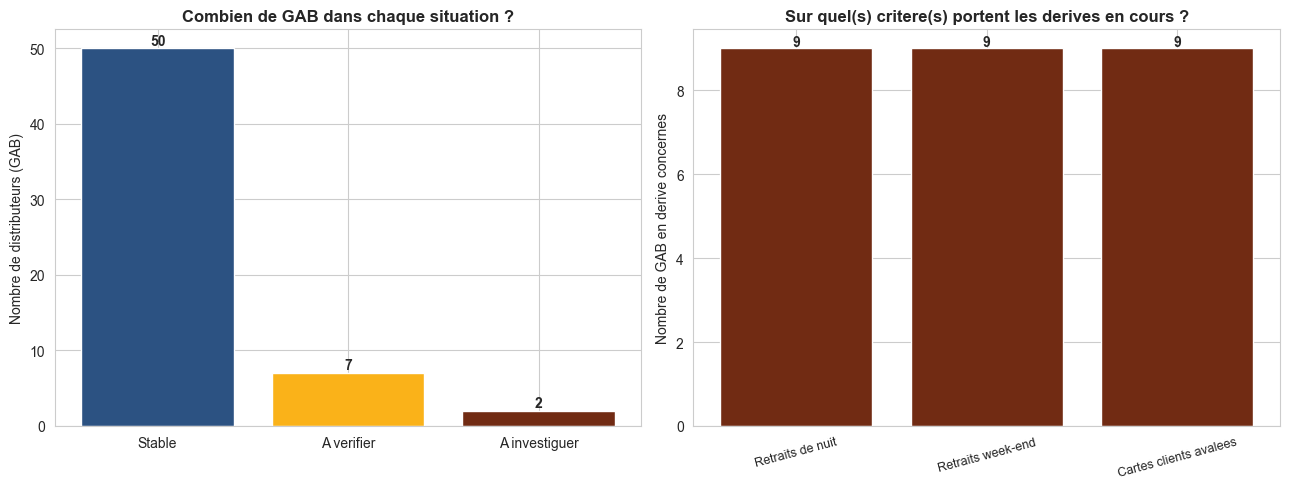

59 distributeurs au total | 7 a verifier | 2 a investiguer en priorite


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Vue d'ensemble reseau - repartition par situation et par critere en cause
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Graphique 1 : combien de GAB dans chaque situation --------------------------
compte_situation = dashboard_metier['Situation'].value_counts()
ordre_situation = ['Stable', 'A verifier (explication saisonniere possible)', 'A investiguer en priorite']
compte_situation = compte_situation.reindex(ordre_situation).fillna(0)
couleurs_situation = [COULEUR_NORMAL, COULEUR_A_VERIFIER, COULEUR_SYSTEMIQUE]

axes[0].bar(range(len(compte_situation)), compte_situation.values, color=couleurs_situation)
axes[0].set_xticks(range(len(compte_situation)))
axes[0].set_xticklabels(['Stable', 'A verifier', 'A investiguer'], fontsize=10)
axes[0].set_ylabel('Nombre de distributeurs (GAB)')
axes[0].set_title('Combien de GAB dans chaque situation ?', fontweight='bold')
for i, v in enumerate(compte_situation.values):
    axes[0].text(i, v + 0.5, str(int(v)), ha='center', fontweight='bold')

# -- Graphique 2 : sur quel(s) critere(s) portent les derives en cours -----------
NOMS_CRITERES_COURTS = {
    'ret_pct_nuit': 'Retraits de nuit',
    'ret_pct_weekend': 'Retraits week-end',
    'taux_capture_horscos_pct': 'Cartes clients avalees',
}
gab_en_derive_liste = dashboard_metier[dashboard_metier['derive_recurrente'].fillna(False)]
compte_critere = {nom: 0 for nom in NOMS_CRITERES_COURTS.values()}
for criteres_txt in gab_en_derive_liste['criteres_responsables']:
    for code, nom in NOMS_CRITERES_COURTS.items():
        if code in criteres_txt:
            compte_critere[nom] += 1

if sum(compte_critere.values()) > 0:
    axes[1].bar(range(len(compte_critere)), list(compte_critere.values()), color=COULEUR_SYSTEMIQUE)
    axes[1].set_xticks(range(len(compte_critere)))
    axes[1].set_xticklabels(list(compte_critere.keys()), fontsize=9, rotation=15)
    axes[1].set_ylabel('Nombre de GAB en derive concernes')
    axes[1].set_title('Sur quel(s) critere(s) portent les derives en cours ?', fontweight='bold')
    for i, v in enumerate(compte_critere.values()):
        axes[1].text(i, v + 0.05, str(int(v)), ha='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Aucun GAB en derive sur la periode', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=11)
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('vue_ensemble_reseau.png', dpi=150, bbox_inches='tight')
plt.show()

print('{} distributeurs au total | {} a verifier | {} a investiguer en priorite'.format(
    len(dashboard_metier), int(compte_situation.get('A verifier (explication saisonniere possible)', 0)),
    int(compte_situation.get('A investiguer en priorite', 0))))

## 7ter. 🔍 Comparatif visuel — avant / pendant la dérive / l'an dernier

Pour chaque GAB en dérive, un visuel qui répond directement à trois questions : *"Comment se
comportait ce GAB avant ?"*, *"Comment se comporte-t-il pendant la dérive ?"*, et *"Faisait-il
déjà ça à la même période l'an dernier ?"*. Les flèches indiquent le sens du changement (▲
hausse, ▼ baisse) et la couleur du fond signale si le comportement est déjà connu à cette
période de l'année (vert = déjà vu, orange = jamais observé à cette période).

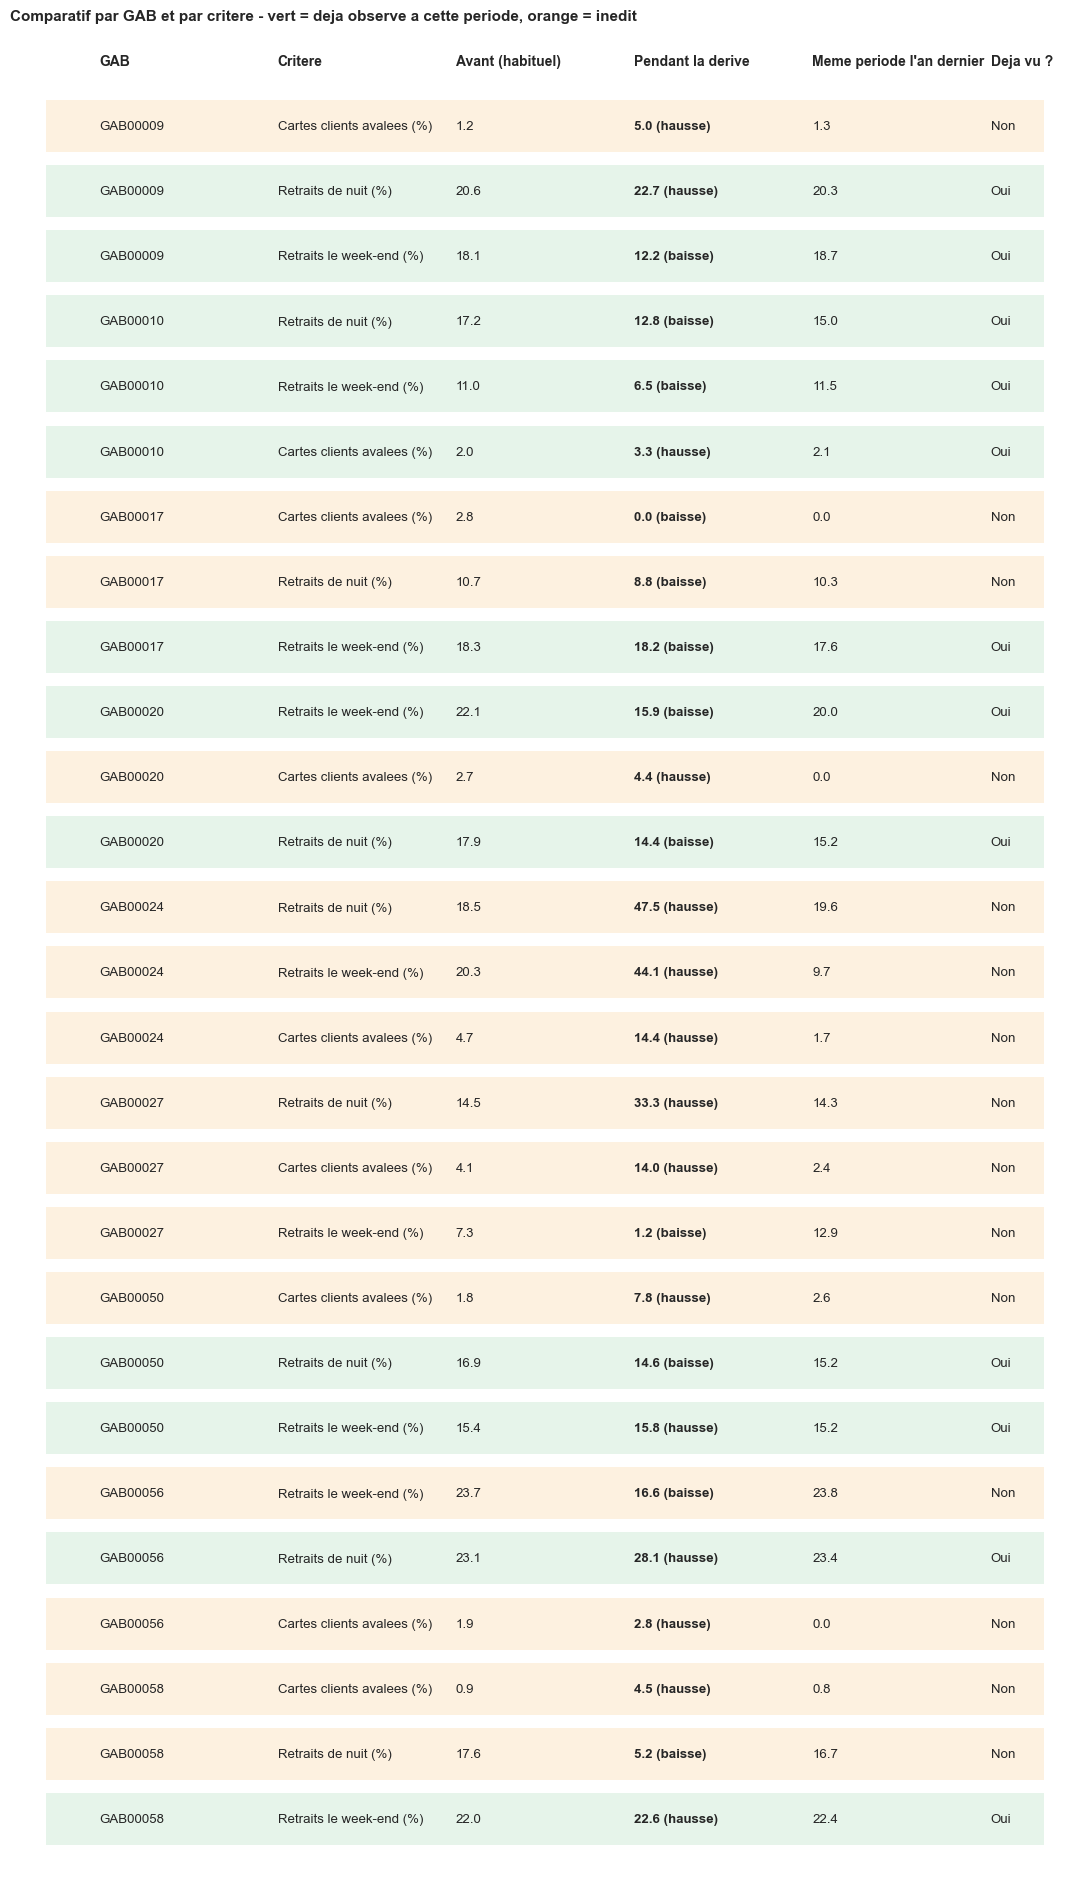

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Tableau comparatif visuel - avant / pendant la derive / meme periode annee precedente
# ══════════════════════════════════════════════════════════════════════════════
NOMS_CRITERES_LISIBLES = {
    'ret_pct_nuit': 'Retraits de nuit (%)',
    'ret_pct_weekend': 'Retraits le week-end (%)',
    'taux_capture_horscos_pct': 'Cartes clients avalees (%)',
}

if len(detail_criteres_derive) > 0:
    n_lignes = len(detail_criteres_derive)
    fig, ax = plt.subplots(figsize=(11, 0.65 * n_lignes + 1.5))
    ax.axis('off')

    colonnes = ['GAB', 'Critere', 'Avant (habituel)', 'Pendant la derive', "Meme periode l'an dernier", 'Deja vu ?']
    n_col = len(colonnes)

    # En-tete
    for j, nom_col in enumerate(colonnes):
        ax.text(j, n_lignes, nom_col, fontweight='bold', ha='left', va='center', fontsize=10)

    for i, (_, ligne) in enumerate(detail_criteres_derive.iterrows()):
        y = n_lignes - 1 - i
        nom_critere = NOMS_CRITERES_LISIBLES.get(ligne['critere'], ligne['critere'])
        avant = ligne['valeur_habituelle_gab']
        pendant = ligne['valeur_pendant_derive']
        an_dernier = ligne['valeur_meme_mois_autres_annees']
        deja_vu = ligne['deja_vu_meme_periode']

        fleche = ''
        if avant is not None and pendant is not None:
            fleche = ' (hausse)' if pendant > avant else (' (baisse)' if pendant < avant else '')

        couleur_fond = '#e6f4ea' if deja_vu else '#fdf1e0'  # vert clair / orange clair
        ax.add_patch(plt.Rectangle((-0.3, y - 0.4), n_col - 0.4, 0.8,
                                     facecolor=couleur_fond, edgecolor='none', zorder=0))

        valeurs_ligne = [
            ligne['num_automate'],
            nom_critere,
            '{:.1f}'.format(avant) if avant is not None else '-',
            '{:.1f}{}'.format(pendant, fleche) if pendant is not None else '-',
            '{:.1f}'.format(an_dernier) if an_dernier is not None else 'pas assez de recul',
            'Oui' if deja_vu else 'Non',
        ]
        for j, val in enumerate(valeurs_ligne):
            poids = 'bold' if j == 3 else 'normal'
            ax.text(j, y, val, ha='left', va='center', fontsize=9.5, fontweight=poids, zorder=1)

    ax.set_xlim(-0.5, n_col - 0.5)
    ax.set_ylim(-1, n_lignes + 0.5)
    ax.set_title('Comparatif par GAB et par critere - vert = deja observe a cette periode, orange = inedit',
                 fontweight='bold', fontsize=11, loc='left')
    plt.tight_layout()
    plt.savefig('comparatif_visuel_derive.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Aucun GAB en derive recurrente sur la periode - pas de comparatif a afficher.')

## 7quater. 🗂️ Fiche détaillée par GAB en dérive

La fiche la plus complète : pour chaque GAB en dérive récurrente, un graphique par critère
concerné montrant **toute l'histoire en un coup d'œil** — l'évolution réelle du critère dans le
temps, la période de dérive surlignée en rouge, et une ligne pointillée verte indiquant le
niveau habituel du GAB à la même période l'an dernier (quand la donnée existe). Si la courbe
pendant la période rouge est proche de la ligne verte, c'est un bon indice que le comportement
est explicable par la saison plutôt que d'être un vrai problème.

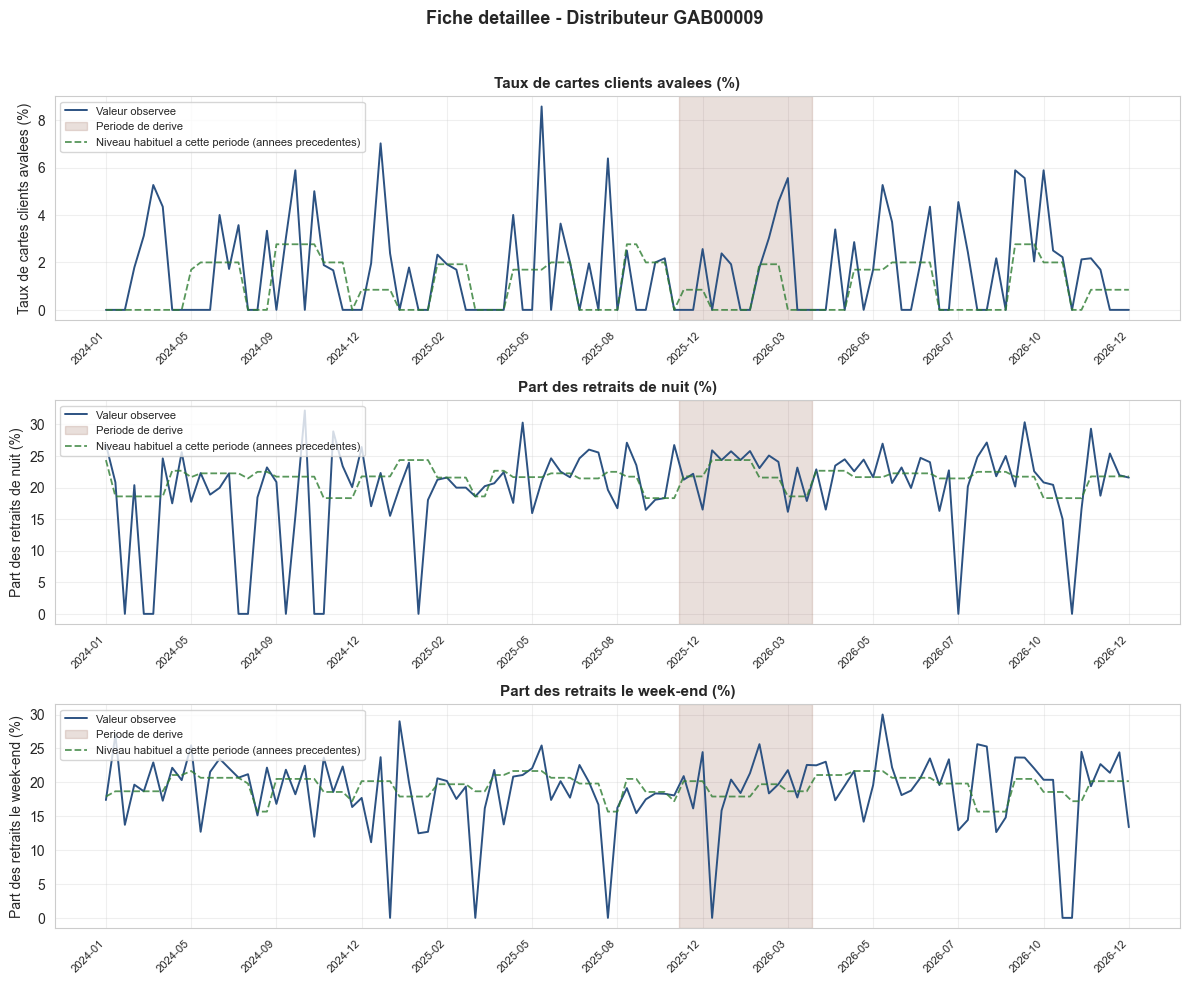

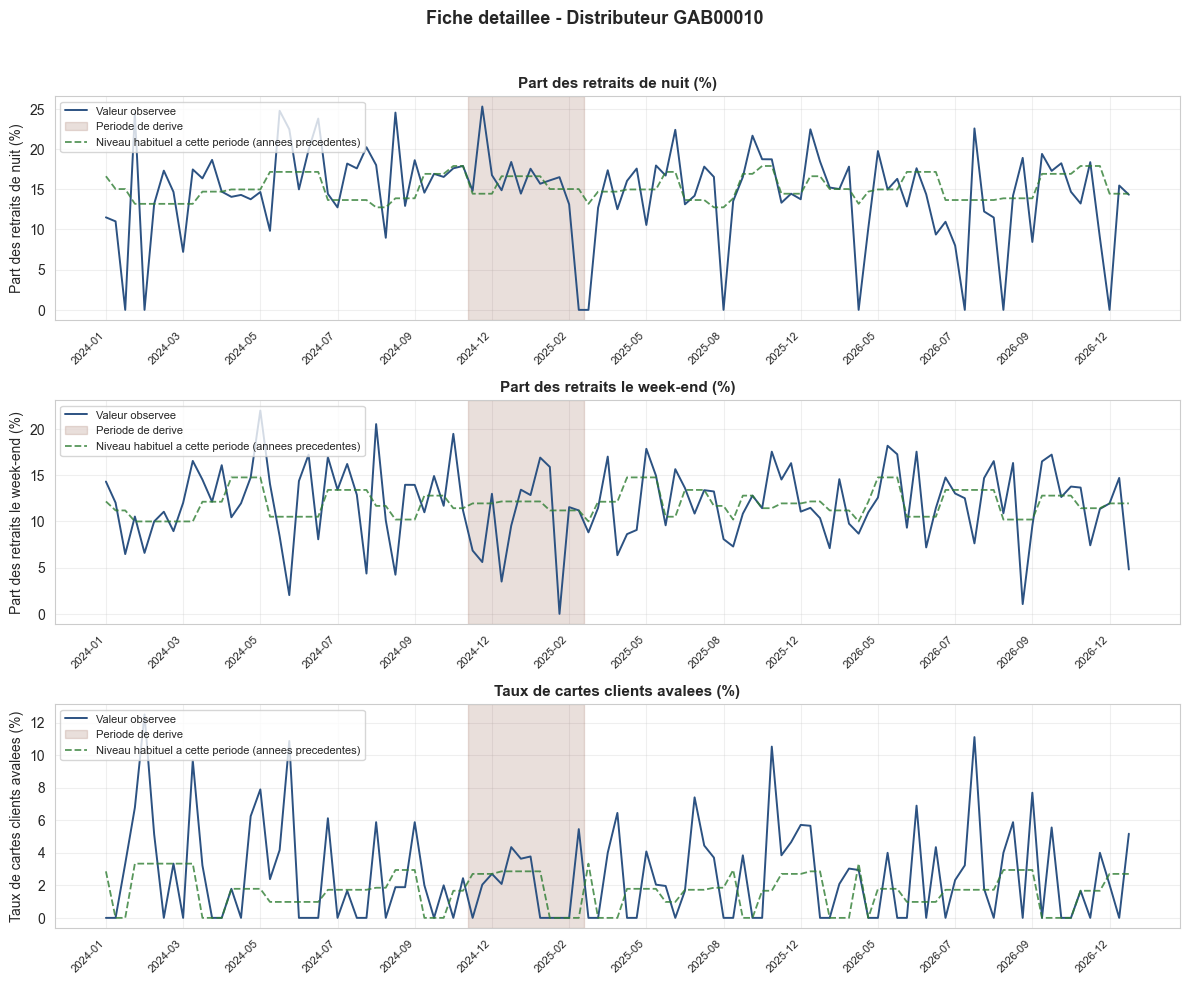

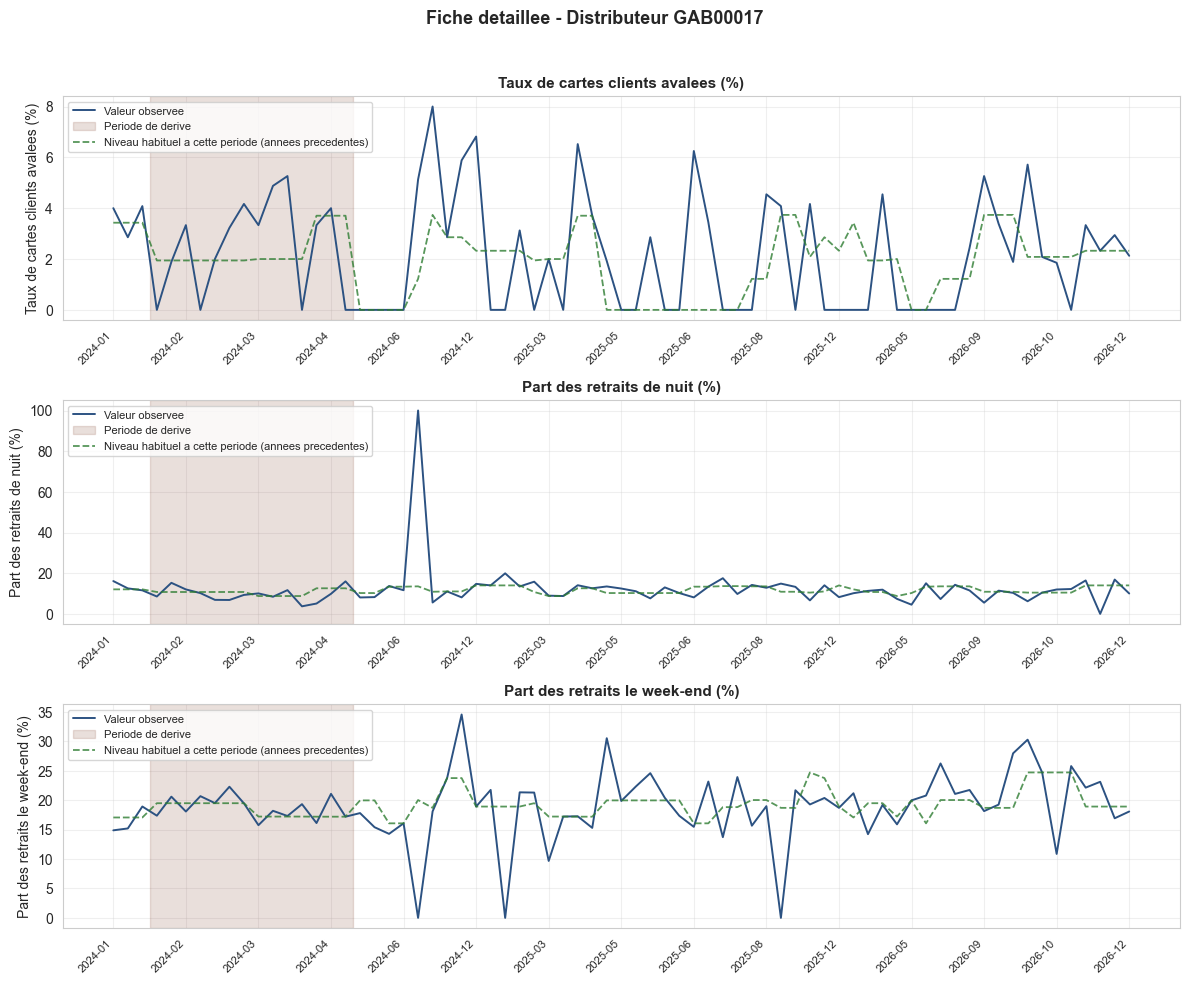

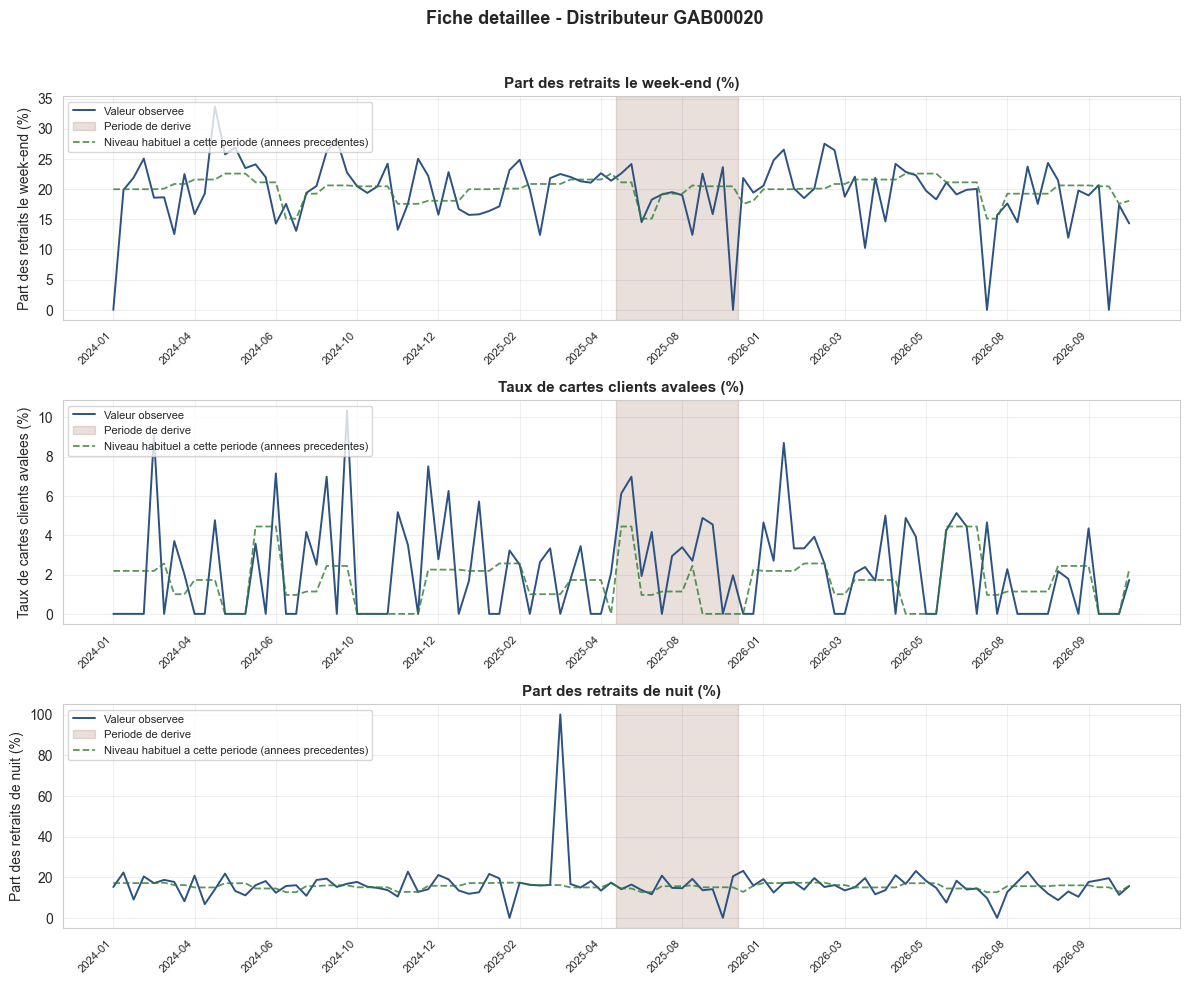

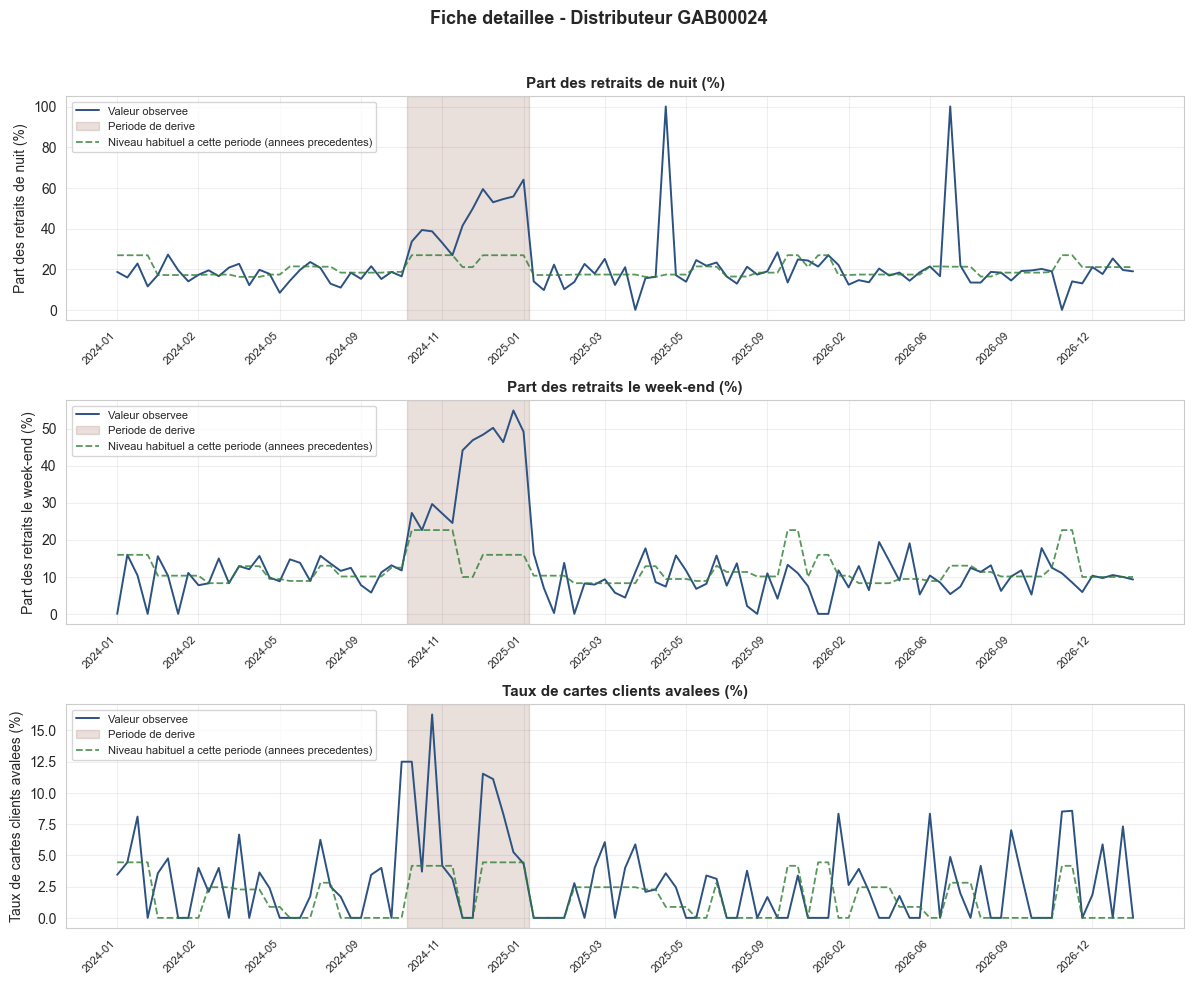

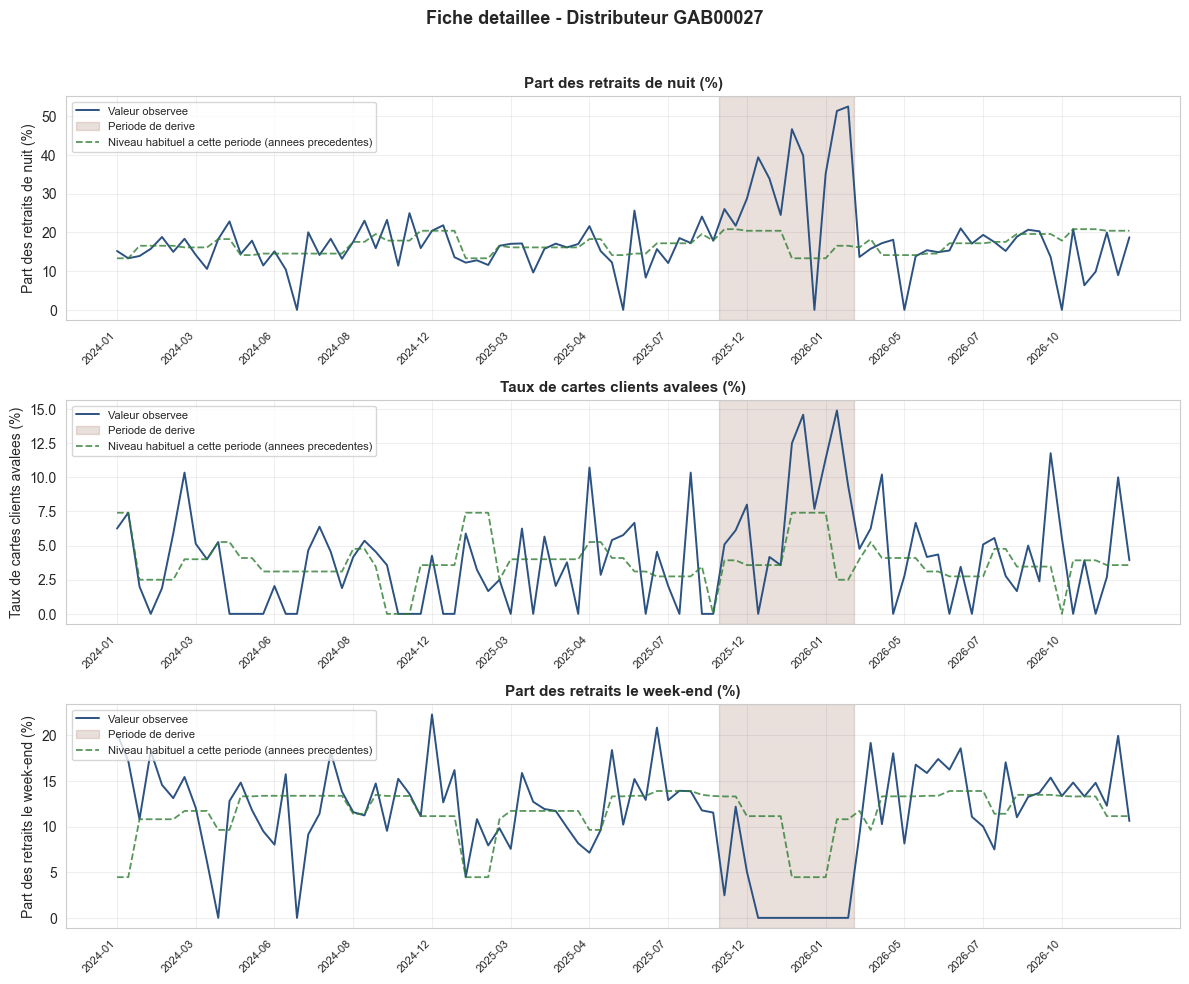

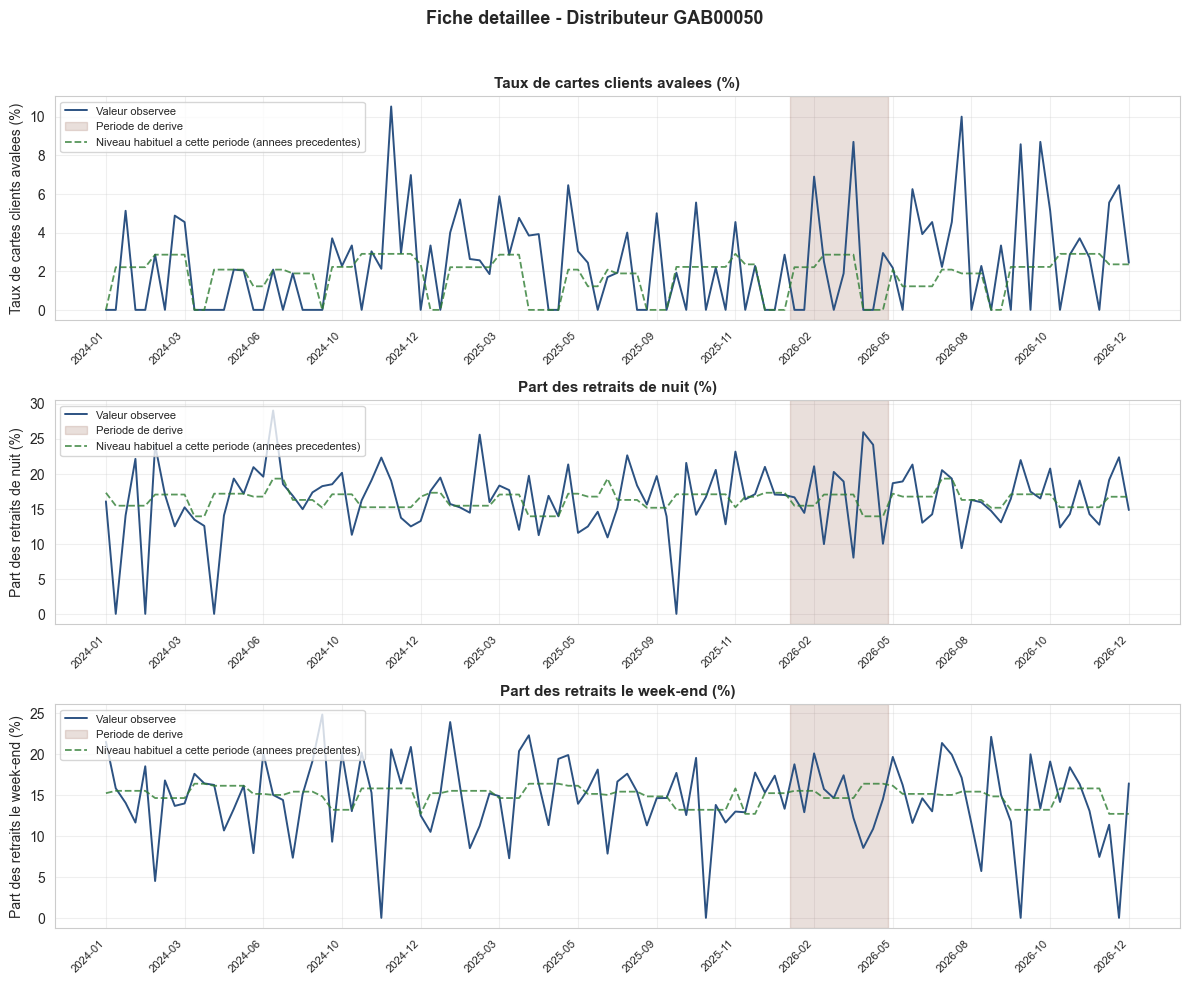

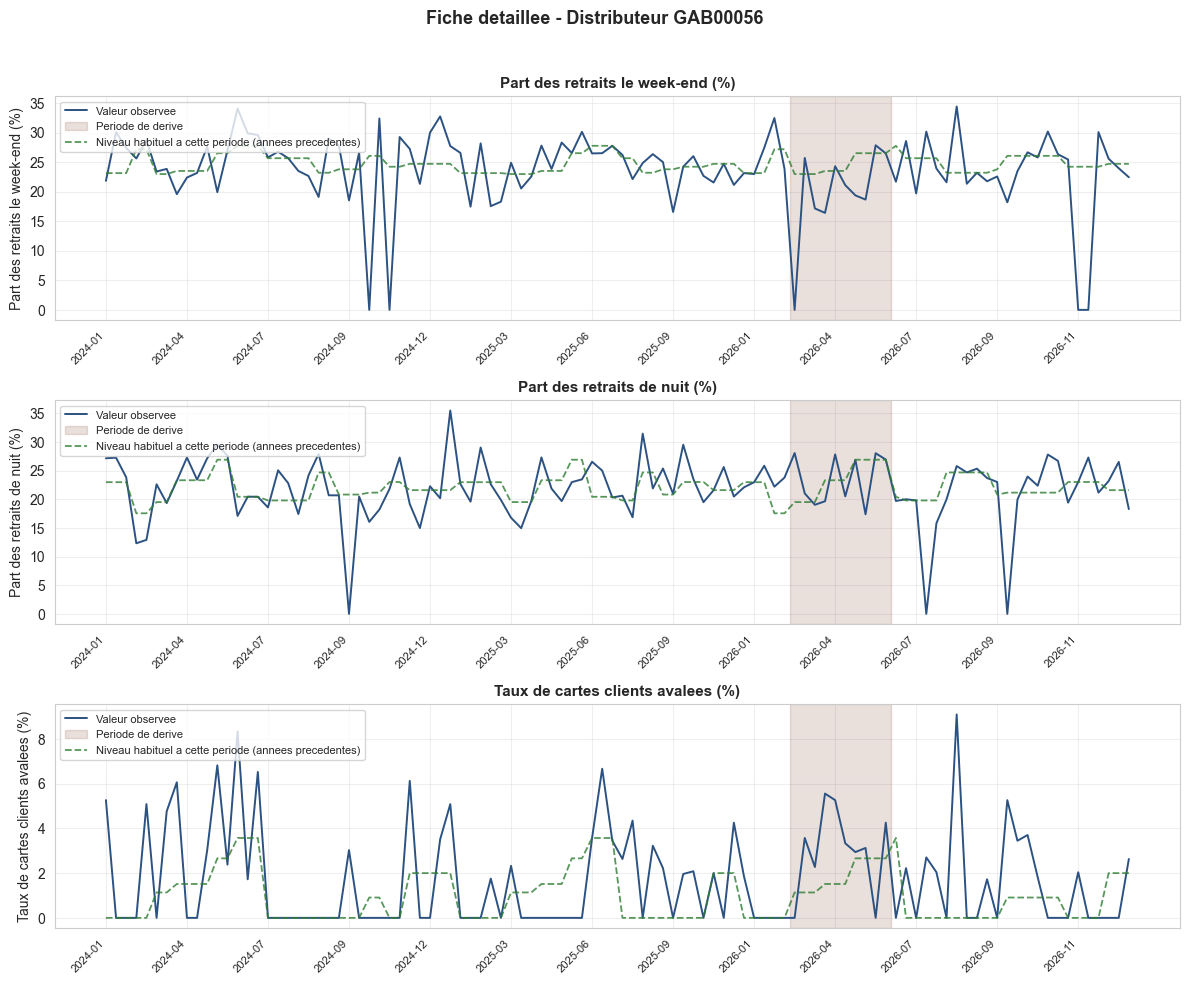

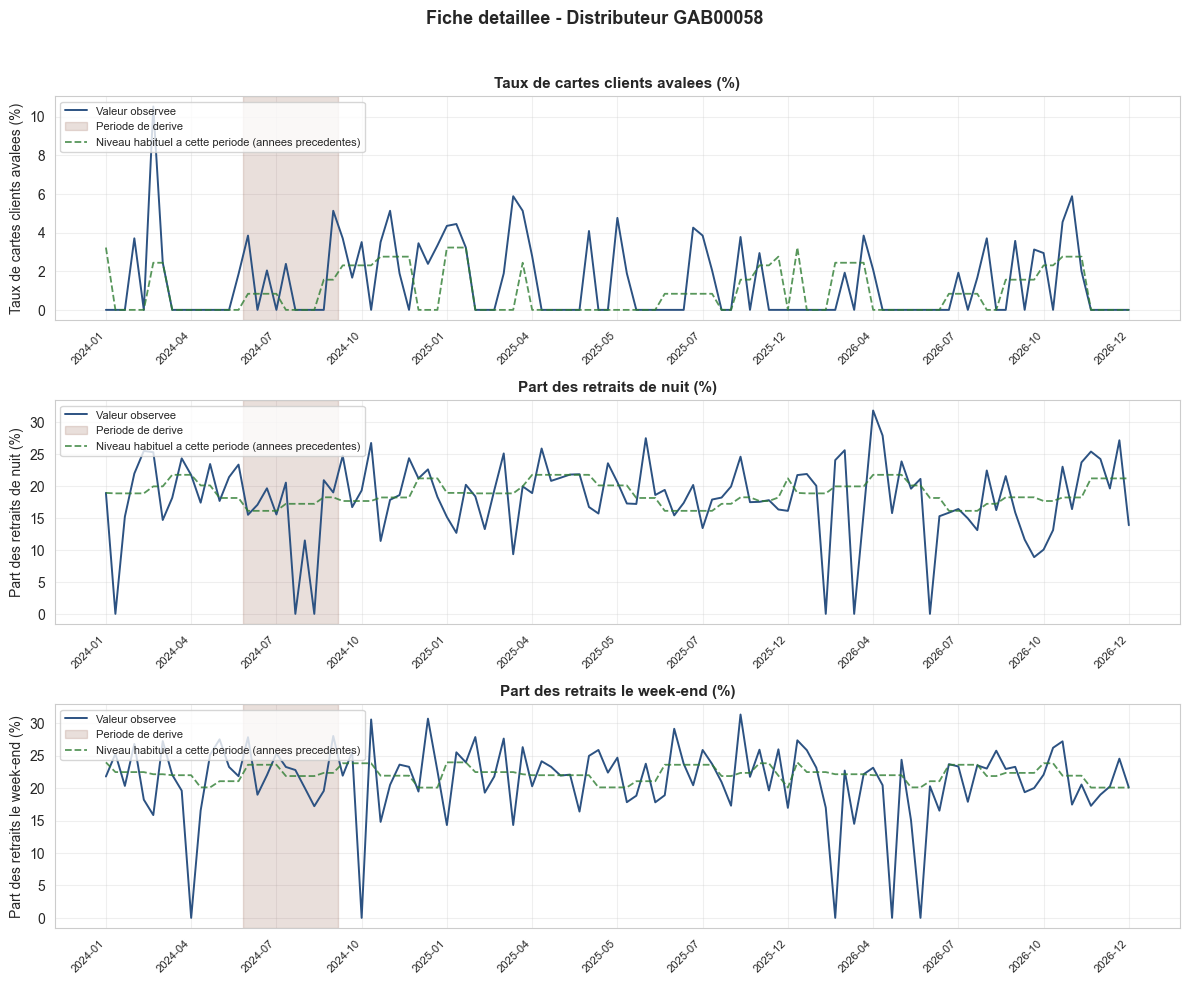

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Fiche detaillee par GAB en derive - un graphique par critere concerne
# ══════════════════════════════════════════════════════════════════════════════
NOMS_CRITERES_LISIBLES = {
    'ret_pct_nuit': 'Part des retraits de nuit (%)',
    'ret_pct_weekend': 'Part des retraits le week-end (%)',
    'taux_capture_horscos_pct': 'Taux de cartes clients avalees (%)',
}


def periode_derive_du_gab(gab_id):
    """Recalcule la meme plus longue serie de mois systemiques que la section 5bis
    (coherence garantie), et retourne l'ensemble des (annee, mois) qui la composent -
    plus fiable qu'un test de sous-chaine sur le texte 'AAAA-MM a AAAA-MM'."""
    sous_agg = agg_mois[agg_mois['num_automate'] == gab_id].reset_index(drop=True)
    meilleure_serie, serie_courante = [], []
    for _, ligne in sous_agg.iterrows():
        if ligne['mois_systemique']:
            serie_courante.append((ligne['annee'], ligne['mois']))
            if len(serie_courante) > len(meilleure_serie):
                meilleure_serie = serie_courante.copy()
        else:
            serie_courante = []
    return set(meilleure_serie)


def tracer_fiche_gab_metier(df, gab_id, criteres_en_cause):
    """Fiche visuelle par GAB, en francais clair, destinee au metier - pas les
    graphiques techniques de la partie 1B (zscore_intra_*, axes en observations
    actives). Un graphique par critere en cause, periode de derive surlignee,
    reference saisonniere (meme mois, annees precedentes) en ligne pointillee."""
    sous_df = df[df['num_automate'] == gab_id].reset_index(drop=True)
    if len(sous_df) == 0 or not criteres_en_cause:
        return

    mois_derive = periode_derive_du_gab(gab_id)
    est_derive = sous_df[['annee', 'mois']].apply(
        lambda r: (r['annee'], r['mois']) in mois_derive, axis=1).to_numpy()

    fig, axes = plt.subplots(len(criteres_en_cause), 1,
                              figsize=(12, 3.2 * len(criteres_en_cause)), sharex=False)
    if len(criteres_en_cause) == 1:
        axes = [axes]

    for ax, critere in zip(axes, criteres_en_cause):
        nom_lisible = NOMS_CRITERES_LISIBLES.get(critere, critere)
        x_labels = ['{}-{:02d}'.format(a, m) for a, m in
                    zip(sous_df['annee'], sous_df['mois'])]
        x = range(len(sous_df))

        ax.plot(x, sous_df[critere], '-', color=COULEUR_NORMAL, linewidth=1.4,
               label='Valeur observee')

        # Periode de derive surlignee - positions reelles (pas un test de sous-chaine)
        if est_derive.any():
            positions = np.where(est_derive)[0]
            i_debut, i_fin = positions[0], positions[-1]
            ax.axvspan(i_debut - 0.5, i_fin + 0.5, color=COULEUR_SYSTEMIQUE, alpha=0.15,
                      label='Periode de derive')

        # Reference saisonniere (meme mois, annees precedentes) - mediane par mois
        ref_saison = df[df['num_automate'] == gab_id].groupby('mois')[critere].median()
        y_ref_saison = sous_df['mois'].map(ref_saison)
        ax.plot(x, y_ref_saison, '--', color='#2e7d32', linewidth=1.3, alpha=0.8,
               label="Niveau habituel a cette periode (annees precedentes)")

        ax.set_ylabel(nom_lisible, fontsize=10)
        ax.set_title(nom_lisible, fontweight='bold', fontsize=11)
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

        pas = max(1, len(x) // 12)
        ax.set_xticks(list(x)[::pas])
        ax.set_xticklabels([x_labels[i] for i in list(x)[::pas]], rotation=45, ha='right', fontsize=8)

    fig.suptitle('Fiche detaillee - Distributeur {}'.format(gab_id), fontweight='bold', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('fiche_metier_{}.png'.format(gab_id), dpi=150, bbox_inches='tight')
    plt.show()


gab_en_derive_liste = derive_recurrente.loc[
    derive_recurrente['derive_recurrente'], 'num_automate'].tolist()

if len(gab_en_derive_liste) == 0:
    print('Aucun GAB en derive recurrente sur la periode - pas de fiche a afficher.')
else:
    for gab in gab_en_derive_liste:
        ligne_gab = tableau_explicatif[tableau_explicatif['num_automate'] == gab]
        if len(ligne_gab) == 0:
            continue
        criteres_txt = ligne_gab['criteres_responsables'].iloc[0]
        criteres_liste = [c.strip() for c in criteres_txt.split(',')] if criteres_txt else []
        tracer_fiche_gab_metier(df, gab, criteres_liste)

## 8. 📌 Conclusion — Vision 1

**Ce que cette vision apporte :**
- Chaque GAB est comparé **exclusivement à sa propre trajectoire** — aucune contamination
  par le comportement du reste du réseau (contrairement à la vision 2).
- Le score d'anomalie (distance de Mahalanobis intra-GAB) tient compte des **corrélations
  entre critères** — deux critères qui bougent souvent ensemble (nuit/week-end par exemple)
  ne sont pas comptés comme deux signaux indépendants, contrairement à un simple comptage de
  seuils dépassés.
- La dérive **récurrente** (mois consécutifs) filtre le bruit ponctuel des vraies tendances,
  et le rapprochement avec la **même période les années précédentes** (3 ans d'historique)
  distingue une vraie anomalie d'un effet saisonnier récurrent (fêtes, vacances...).
- Le tableau destiné au métier (section 6bis) priorise sur le **volume réel de cartes
  clients avalées**, pas sur un score statistique seul — plus parlant pour juger de
  l'urgence d'une intervention terrain.
- La fenêtre de référence se **fige dès qu'une rupture s'installe** (2 observations
  consécutives hors norme), au lieu de continuer à glisser en continu — corrige un défaut
  identifié empiriquement où une dérive durable n'était détectée que sur ses 2-3 premières
  observations avant d'être "digérée" par la moyenne roulante.

**⚠️ Limite honnête, mesurée sur un test non biaisé — à lire avant toute mise en production :**

Le dataset de démo a été régénéré de façon **non ciblée** (processus aléatoire décidant, pour
chaque GAB indépendamment, s'il traverse une dérive, sans qu'on choisisse à l'avance lesquels)
pour tester réellement le pipeline plutôt que de confirmer un résultat pré-fabriqué. Résultat
mesuré sur ce test : sur 6 GAB réellement mis en dérive par le générateur, le pipeline en a
retrouvé **3** (50% de rappel), et a signalé à tort **7 GAB stables sur 54** comme étant en
dérive récurrente (~13% de faux positifs). Ces chiffres n'ont de valeur que sur CE tirage
aléatoire précis — ils varieront à chaque régénération du dataset et ne doivent pas être lus
comme une performance garantie. Ils indiquent en revanche un ordre de grandeur réaliste :
**le modèle rate une dérive sur deux et déclenche une fausse alerte de temps en temps** — un
niveau de fiabilité correct pour une première version outillant l'attention du métier
(pré-filtrage à vérifier), mais insuffisant pour une décision automatique sans supervision
humaine.

**Limites et notes méthodologiques :**
1. **Fenêtre glissante en observations actives, pas en jours calendaires** — un GAB peu actif
   met plus de temps calendaire à accumuler assez d'historique pour un score fiable.
2. **Aucune vérité terrain réelle disponible** — les chiffres de rappel/faux positifs ci-dessus
   viennent d'un dataset **simulé**, pas de GAB réellement en panne. La seule vraie validation
   possible reste un échantillon de GAB effectivement signalés par le métier sur données de
   production, comme déjà noté en v12. Tant que ça n'a pas été fait, aucun chiffre de ce
   notebook ne doit être présenté comme une performance prouvée.
3. **`taux_capture_horscos_pct` est une colonne dérivée** (`cap_nb / (ret_nb_horscos + 1)`) —
   `cap_nb` est déjà filtré hors-COS dans le SQL source (`ficheidentité.sql`), les captures COS
   (comptes/cartes internes, hors clientèle classique) sont donc **volontairement exclues** du
   calcul : une carte COS avalée est un événement normal, pas un signal à surveiller. À faire
   valider/aligner avec le SQL source si une colonne équivalente existe déjà.
4. **Les seuils (`SEUIL_Z_RUPTURE=2.0`, `SEUIL_STREAK_RECURRENT=3`,
   `N_HORS_NORME_POUR_GELER=2`, `N_STABLE_POUR_DEGELER=3`, `PCT_SEUIL_MAHALANOBIS=98`) sont
   choisis par convention statistique ou ajustés empiriquement sur ce dataset simulé — aucun
   n'a été calibré avec le métier sur des cas réels.** Une vraie calibration nécessiterait un
   échantillon de GAB confirmés en panne pour maximiser le rappel à faux-positif acceptable
   fixé par le métier, pas par le data scientist seul.
5. **Performance mesurée, pas juste estimée.** Le calcul du z-score à fenêtre figée et le
   score de Mahalanobis reposent sur des boucles Python (pas vectorisées) par GAB et par
   observation — complexité linéaire en nombre total d'observations (pas quadratique). Mesuré
   sur ce dataset (60 GAB, ~5 700 lignes) : environ 0.4s pour le z-score à fenêtre figée (3
   critères) et 0.75s pour Mahalanobis, soit ~0.0002s/observation. Projection linéaire à 10x
   le volume (~600 GAB) : quelques secondes ; à 100x (~6 000 GAB, plusieurs années
   d'historique journalier) : de l'ordre de la minute. Reste à confirmer sur un vrai volume de
   production (cette projection suppose une croissance linéaire, pas garantie en pratique —
   à revalider avant mise en prod, pas juste extrapoler).
6. Cette vision est complémentaire de la **vision 2** (comparaison entre GAB / familles) et de
   la **vision 3** (sixième sens) — les trois doivent être lues ensemble pour une image complète.